# Mood Evolution — ML Pipeline + Live App

Install dependencies

In [ ]:
!pip install -q scikit-learn numpy torch matplotlib pillow streamlit pyngrok

In [1]:
%%writefile mood_evolution.py

# ==============================================================================
# IMPORTS — every external dependency this file needs, once, here.
# ==============================================================================
import os
import json
import pickle
from datetime import datetime
import datetime as dt
import hashlib
import math
import random
import itertools
import colorsys
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import streamlit as st
except ImportError:
    st = None

Writing mood_evolution.py


DATA & CONSTANTS

The 11 mood categories and their fixed VAD anchor points, plus the 44-sentence synthetic bootstrap training set.

In [2]:
%%writefile -a mood_evolution.py

CATEGORY_ANCHORS_VAD = {
    "stress":  (-0.55,  0.75, -0.30),
    "anger":   (-0.75,  0.90,  0.50),
    "calm":    ( 0.50, -0.45,  0.40),
    "clarity": ( 0.60,  0.35,  0.50),
    "focus":   ( 0.60,  0.50,  0.60),
    "sad":     (-0.65,  0.15, -0.50),
    "fog":     (-0.42,  0.15, -0.60),
    "heavy":   (-0.58,  0.10, -0.50),
    "hope":    ( 0.60,  0.40,  0.20),
    "joy":     ( 0.78,  0.60,  0.50),
    "light":   ( 0.63,  0.35,  0.30),
}

CATEGORIES = list(CATEGORY_ANCHORS_VAD.keys())

SEED_EXAMPLES = {
    "stress": [
        "Back-to-back meetings and deadlines have my chest tight and my mind racing.",
        "I feel so overwhelmed and anxious, there's too much pressure today.",
        "Tense all day, panic keeps creeping in whenever I check my inbox.",
        "Too busy, too much on my plate, I can't catch my breath.",
    ],
    "anger": [
        "I am furious about how that meeting went, everything feels frustrating.",
        "Rage bubbling under the surface, I snapped at everyone today.",
        "Frustrated and angry, nothing is going the way it should.",
        "Irritated all day, small things kept setting me off.",
    ],
    "calm": [
        "A peaceful morning, slow coffee and gentle light, I feel settled.",
        "Breathing deeply, grounded and still, everything feels safe.",
        "Quiet and at ease, I let a few things go softly today.",
        "Resting today, calm and gentle, nothing urgent to hold onto.",
    ],
    "clarity": [
        "Everything feels clear today, a sharp sense of certainty.",
        "My thoughts are bright and focused, the fog has lifted.",
        "A clean, clear headspace, I can finally see the way forward.",
        "Certain and clear-headed, the confusion from last week is gone.",
    ],
    "focus": [
        "Determined and driven, I feel capable and purposeful today.",
        "Sharp focus all morning, strong and gathered.",
        "Powerful sense of purpose, I know exactly what I need to do.",
        "Disciplined and focused, I got through everything I planned.",
    ],
    "sad": [
        "Empty and lonely today, a slow ache that won't leave.",
        "I feel low and heavy-hearted, close to tears.",
        "A quiet grief sitting with me, everything feels muted.",
        "Down and withdrawn, I just feel sad without a clear reason.",
    ],
    "fog": [
        "Confused and unclear, my thoughts feel blurry and lost.",
        "Everything is foggy today, I can't find a clear thought.",
        "Lost in the shadows of my own head, nothing makes sense.",
        "Unclear and hazy, I can't tell what I'm actually feeling.",
    ],
    "heavy": [
        "Exhausted and drained, I feel stuck carrying something heavy.",
        "Numb and tired, everything feels like too much effort.",
        "Heavy limbs, heavy mind, I can barely move today.",
        "Drained and stuck, even small tasks feel like too much.",
    ],
    "hope": [
        "Something is lifting, a fragile hope is returning.",
        "I feel like I'm slowly healing and becoming lighter.",
        "A quiet hope rising, things feel like they're turning around.",
        "Emerging from a hard stretch, a little more hopeful each day.",
    ],
    "joy": [
        "Grateful and alive, today felt genuinely happy and free.",
        "Bursting with joy, I feel loved and excited about everything.",
        "A beautiful day, I feel light, happy, and full of love.",
        "Excited and joyful, everything today felt easy and good.",
    ],
    "light": [
        "Warm golden light this morning, everything felt gentle and glowing.",
        "A bright shine over the day, warmth breaking through.",
        "Soft warm light, everything feels touched by gold.",
        "Everything glowed a little today, warm and bright.",
    ],
}

Appending to mood_evolution.py


EMOTIONAL MAPPER  

Maps a probability distribution over categories into continuous VAD + clarity/turbulence: a fixed, designed transformation, not a fitted model.

In [3]:
%%writefile -a mood_evolution.py

_READING_MAP = {
    "stress": "A charged, restless current", "anger": "Heat rising to the surface",
    "calm": "Settling into quiet ground", "clarity": "A clearing — light finding form",
    "focus": "Gathered, deliberate, gilded", "sad": "A slow, low tide",
    "fog": "Soft uncertainty, half-lit", "heavy": "Weight, slowly loosening",
    "hope": "Something becoming", "joy": "Open and luminous", "light": "Warmth breaking through",
}


class EmotionalMapper:
    def __init__(self, category_anchors=None):
        self.anchors = category_anchors or CATEGORY_ANCHORS_VAD

    def map(self, posterior):
        """posterior: {category: probability}, e.g. classifier output.
        Returns: {valence, arousal, dominance, clarity, turbulence,
                   top_category, style, reading, themes}
        style/reading/themes are, like the rest of this class, fixed designed
        logic (ported directly from the original JS app), not learned —
        kept here rather than in the frontend so the client needs zero local
        decision logic, only rendering.
        """
        valence = arousal = dominance = 0.0
        for category, p in posterior.items():
            v, a, d = self.anchors.get(category, (0.0, 0.0, 0.0))
            valence += p * v
            arousal += p * a
            dominance += p * d

        clarity = float(np.clip(
            0.5 + posterior.get("clarity", 0) * 0.5 + posterior.get("light", 0) * 0.3
            - posterior.get("fog", 0) * 0.6 - posterior.get("stress", 0) * 0.2,
            0, 1,
        ))
        turbulence = float(np.clip(
            posterior.get("stress", 0) * 0.6 + posterior.get("anger", 0) * 0.6
            - posterior.get("calm", 0) * 0.4 + (arousal + 1) / 2 * 0.2,
            0, 1,
        ))

        themes = sorted(posterior.keys(), key=lambda c: -posterior[c])
        top_category = themes[0]

        # style selection — same thresholds as the original app's buildStyle logic,
        # rescaled from raw theme-score sums onto 0..1 posterior probabilities
        calm_w = posterior.get("calm", 0) + 0.4 * posterior.get("sad", 0)
        prism_w = posterior.get("clarity", 0) + posterior.get("focus", 0) + 0.6 * posterior.get("light", 0)
        silk_w = posterior.get("heavy", 0) + posterior.get("fog", 0) + posterior.get("stress", 0) + 0.1
        if calm_w >= prism_w and calm_w >= silk_w and calm_w > 0.25:
            style = "cloud"
        elif prism_w >= silk_w and prism_w > 0.3:
            style = "prism"
        else:
            style = "silk"
        if arousal < -0.25 and valence >= -0.1:
            style = "cloud"

        reading = _READING_MAP.get(top_category) or (
            "A gentle brightening" if valence > 0.25 else
            "A muted, inward turn" if valence < -0.25 else
            "A quiet, even keel"
        )

        return {
            "valence": float(valence),
            "arousal": float(arousal),
            "dominance": float(dominance),
            "clarity": clarity,
            "turbulence": turbulence,
            "top_category": top_category,
            "style": style,
            "reading": reading,
            "themes": themes,
        }

Appending to mood_evolution.py


CURATED PALETTE MAPPER

The actual colour-design rule: a curated affective colour-mapping system, deterministic, hand-tuned. This is the honest core of 'colour generation' in this project.

In [4]:
%%writefile -a mood_evolution.py

def hsl_to_rgb01(h, s, l):
    h = (h % 360) / 360.0
    r, g, b = colorsys.hls_to_rgb(h, l, s)  # note: colorsys takes (h, l, s), not (h, s, l)
    return np.array([r, g, b])


def rgb01_to_hex(rgb01):
    return "#{:02x}{:02x}{:02x}".format(*(np.clip(rgb01, 0, 1) * 255).astype(int))


def deterministic_palette(valence, energy01, clarity, turbulence, theme_scores):
    """The rule itself. 4 colours out: [deep base, mid, vibrant accent,
    luminous highlight]. theme_scores: dict of category -> weight, used
    only to pick which hue family applies (see the if/elif chain) — this
    is a discrete branch, not a smooth learned function."""
    T = theme_scores or {}
    if T.get("anger", 0) > 0.5 or T.get("stress", 0) > 1.0:
        hue, accent_hue, sat = 8, 350, 0.85
    elif T.get("calm", 0) > 0.4:
        hue, accent_hue, sat = 255, 285, 0.45
    elif T.get("clarity", 0) > 0.3 or T.get("light", 0) > 0.3:
        hue, accent_hue, sat = 45, 320, 0.6
    elif T.get("focus", 0) > 0.4:
        hue, accent_hue, sat = 42, 270, 0.55
    elif T.get("sad", 0) > 0.4:
        hue, accent_hue, sat = 225, 260, 0.4
    elif T.get("fog", 0) > 0.3 or T.get("heavy", 0) > 0.3:
        hue, accent_hue, sat = 265, 300, 0.4
    elif T.get("hope", 0) > 0.3 or T.get("joy", 0) > 0.3:
        hue, accent_hue, sat = 330, 45, 0.6
    else:
        hue, accent_hue, sat = 270, 320, 0.45

    hue += valence * 12
    sat = np.clip(sat + turbulence * 0.2 - (0.05 if valence < 0 else 0), 0.25, 0.9)

    base_l = 0.05 + (1 - energy01) * 0.02
    c0 = hsl_to_rgb01(hue + 200, sat * 0.4, base_l)
    c1 = hsl_to_rgb01(accent_hue, sat * 0.7, 0.18 + turbulence * 0.06)
    c2 = hsl_to_rgb01(hue, sat, 0.5 + clarity * 0.08)
    hi_l = 0.72 + clarity * 0.14
    c3 = hsl_to_rgb01(hue + 18, max(0.18, sat * 0.45), hi_l)
    return np.concatenate([c0, c1, c2, c3])  # 12 values: RGB x 4 stops


def deterministic_palette_hex(valence, energy01, clarity, turbulence, theme_scores):
    raw = deterministic_palette(valence, energy01, clarity, turbulence, theme_scores)
    return [rgb01_to_hex(s) for s in raw.reshape(4, 3)]


# --- named presets for direct user selection (the palette-override UI) ----
# Also not ML: these are 6 hand-picked points fed through the same rule
# above, so a user can pick "Stress" and get a colour scheme without typing
# anything, or override whatever the pipeline auto-detected.
PRESET_DEFS = {
    "calm":    dict(label="Calm",    theme_scores={"calm": 1.2},                valence=0.6,  energy01=0.25, clarity=0.5,  turbulence=0.05),
    "clarity": dict(label="Clarity", theme_scores={"clarity": 1, "light": 0.6}, valence=0.6,  energy01=0.5,  clarity=0.85, turbulence=0.1),
    "warmth":  dict(label="Warmth",  theme_scores={"hope": 0.8, "joy": 0.6},    valence=0.75, energy01=0.55, clarity=0.6,  turbulence=0.15),
    "fog":     dict(label="Fog",     theme_scores={"fog": 0.8, "heavy": 0.5},   valence=-0.3, energy01=0.3,  clarity=0.25, turbulence=0.3),
    "stress":  dict(label="Stress",  theme_scores={"stress": 1.1, "anger": 0.3}, valence=-0.5, energy01=0.85, clarity=0.3,  turbulence=0.75),
    "sorrow":  dict(label="Sorrow",  theme_scores={"sad": 0.9},                 valence=-0.6, energy01=0.2,  clarity=0.35, turbulence=0.2),
}

# Which diary-classifier category a preset choice implies, for feeding a
# real-time training correction back into the (actually learned) classifier
# when a user picks a preset. Also not ML itself — just a lookup table.
PRESET_TO_CATEGORY = {"calm": "calm", "clarity": "clarity", "warmth": "hope", "fog": "fog", "stress": "stress", "sorrow": "sad"}


def preset_palette(preset_key):
    d = PRESET_DEFS[preset_key]
    return deterministic_palette_hex(d["valence"], d["energy01"], d["clarity"], d["turbulence"], d["theme_scores"])

Appending to mood_evolution.py


DIARY CLASSIFIER  - Multinomial Naive Bayes

The one place text gets classified into a mood category. Functionally necessary, alongside the forecaster.

In [5]:
%%writefile -a mood_evolution.py

class DiaryMoodClassifier:
    def __init__(self, seed_examples=None):
        seed_examples = seed_examples or SEED_EXAMPLES
        self.texts = []
        self.labels = []
        for category, examples in seed_examples.items():
            for text in examples:
                self.texts.append(text)
                self.labels.append(category)
        self.vectorizer = CountVectorizer(lowercase=True, stop_words="english")
        self.model = MultinomialNB(alpha=1.0)  # alpha=1.0 -> Laplace (add-1) smoothing
        self.mapper = EmotionalMapper(CATEGORY_ANCHORS_VAD)
        self._fit()

    def _fit(self):
        X = self.vectorizer.fit_transform(self.texts)
        self.model.fit(X, self.labels)
        # Baseline: what a word with ZERO evidence (all-zero feature vector)
        # would predict, driven purely by class priors. With 11 categories
        # split roughly 6 positive-valence / 5 negative-valence, this baseline
        # is NOT zero — it's slightly positive. Subtracting it from each
        # word's raw blended valence is necessary, not cosmetic: without it,
        # a genuinely negative word like "anxious" can come out with a
        # POSITIVE score, because its true category gets a modest probability
        # boost while five or six untouched positive-valence categories each
        # keep their small prior share, and mL positive category-count with
        # tiny training data. See word_score() below for where this is used.
        import scipy.sparse as sp
        zero_vec = sp.csr_matrix((1, len(self.vectorizer.vocabulary_)))
        proba = self.model.predict_proba(zero_vec)[0]
        self._baseline_valence = sum(
            p * CATEGORY_ANCHORS_VAD[c][0] for c, p in zip(self.model.classes_, proba)
        )

    def learn(self, text, category):
        """Online correction: record a user-confirmed (text, category) pair
        and retrain. This is the mechanism that lets the model personalise
        to one person's vocabulary over time."""
        if category not in CATEGORY_ANCHORS_VAD:
            raise ValueError(f"Unknown category: {category}")
        self.texts.append(text)
        self.labels.append(category)
        self._fit()

    def analyze(self, text):
        """Return a mood estimate for a diary entry.

        Classification (learned) happens here. The resulting probability
        distribution is then handed to EmotionalMapper — a separate,
        non-learned component — to become VAD coordinates + clarity/turbulence.
        This split is deliberate: everything above the mapper.map() call is
        the trained model; everything inside EmotionalMapper is designed logic.

        Returns a dict with:
          posterior      - {category: probability} from the classifier
          top_category   - the single most likely category
          valence        - [-1, 1]
          arousal        - [-1, 1]  (previously called "energy")
          dominance      - [-1, 1]  (new VAD third axis — see seed_data.py)
          energy         - alias for arousal, kept so existing callers
                            (art_color_model, archive_clustering, etc.) don't break
          clarity        - derived score, [0, 1]
          turbulence     - derived score, [0, 1]
        """
        X = self.vectorizer.transform([text])
        proba = self.model.predict_proba(X)[0]
        classes = list(self.model.classes_)
        posterior = dict(zip(classes, proba))

        mapped = self.mapper.map(posterior)
        mapped["energy"] = mapped["arousal"]  # backward-compatible alias
        mapped["posterior"] = posterior
        return mapped

    def word_score(self, word):
        """Per-word valence score for the word-chip UI: classify this single
        word on its own, blend the resulting posterior against category
        valence anchors, then subtract the no-evidence baseline (see _fit)
        so the sign reflects this word's actual pull, not an artifact of
        having more positive- than negative-valence categories."""
        X = self.vectorizer.transform([word])
        if X.nnz == 0:  # word not in vocabulary — no signal
            return 0.0
        proba = self.model.predict_proba(X)[0]
        classes = list(self.model.classes_)
        raw = sum(p * CATEGORY_ANCHORS_VAD[cat][0] for cat, p in zip(classes, proba))
        return float(raw - self._baseline_valence)

    def training_set_size(self):
        return len(self.texts)

Appending to mood_evolution.py


ART COLOUR MODEL - Linear Regression

Learns to reproduce rule from a mood vector. One mood, one fixed output — not generative.

In [6]:
%%writefile -a mood_evolution.py

def _random_theme_scores(rng):
    scores = {c: 0.0 for c in CATEGORIES}
    dominant = rng.choice(CATEGORIES)
    scores[dominant] = rng.uniform(0.3, 1.4)
    for _ in range(rng.integers(0, 3)):
        scores[rng.choice(CATEGORIES)] += rng.uniform(0.05, 0.4)
    return scores


class ArtColorModel:
    def __init__(self, n_synthetic_samples=800, random_state=42):
        rng = np.random.default_rng(random_state)
        self._X = []
        self._y = []
        self.n_synthetic_samples = n_synthetic_samples
        for _ in range(n_synthetic_samples):
            valence = rng.uniform(-1, 1)
            energy01 = rng.uniform(0, 1)
            clarity = rng.uniform(0, 1)
            turbulence = rng.uniform(0, 1)
            theme_scores = _random_theme_scores(rng)
            features = self._features(valence, energy01, clarity, turbulence, theme_scores)
            target = deterministic_palette(valence, energy01, clarity, turbulence, theme_scores)
            self._X.append(features)
            self._y.append(target.tolist())
        self.model = LinearRegression()
        self.n_real_corrections = 0  # tracks how many REAL (non-synthetic) examples have been added
        self._fit()

    @staticmethod
    def _features(valence, energy01, clarity, turbulence, theme_scores):
        theme_scores = theme_scores or {}
        return [valence, energy01, clarity, turbulence] + [theme_scores.get(c, 0.0) for c in CATEGORIES]

    @staticmethod
    def _hex_to_rgb01(hexcolor):
        h = hexcolor.lstrip("#")
        return [int(h[i:i + 2], 16) / 255 for i in (0, 2, 4)]

    def _fit(self):
        self.model.fit(np.array(self._X), np.array(self._y))

    def predict_palette(self, valence, energy01, clarity, turbulence, theme_scores):
        features = [self._features(valence, energy01, clarity, turbulence, theme_scores)]
        raw = np.clip(self.model.predict(np.array(features))[0], 0, 1)
        stops = raw.reshape(4, 3)
        return ["#{:02x}{:02x}{:02x}".format(*(stop * 255).astype(int)) for stop in stops]

    def learn(self, valence, energy01, clarity, turbulence, theme_scores, chosen_hex_palette):
        """Record a REAL user's manual palette choice as a training example
        and refit. This is the only source of non-synthetic data this model
        ever sees. chosen_hex_palette: list of 4 hex strings."""
        if len(chosen_hex_palette) != 4:
            raise ValueError("Expected exactly 4 hex colours (base, mid, accent, highlight).")
        features = self._features(valence, energy01, clarity, turbulence, theme_scores)
        target = [c for hexcolor in chosen_hex_palette for c in self._hex_to_rgb01(hexcolor)]
        self._X.append(features)
        self._y.append(target)
        self.n_real_corrections += 1
        self._fit()

    def training_set_size(self):
        return len(self._X)

    def data_summary(self):
        return {
            "synthetic_examples": self.n_synthetic_samples,
            "real_corrections": self.n_real_corrections,
            "total_training_examples": len(self._X),
            "fraction_real": self.n_real_corrections / max(1, len(self._X)),
        }

Appending to mood_evolution.py


CVAE ART MODEL - Conditional VAE, PyTorch

One mood, a *distribution* to sample from. Trained entirely on synthetic data.

In [7]:
%%writefile -a mood_evolution.py

COND_DIM = 5   # valence, arousal, dominance, clarity, turbulence
X_DIM = 12     # 4 RGB stops
LATENT_DIM = 4


class _Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(X_DIM + COND_DIM, 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU())
        self.mu = nn.Linear(16, LATENT_DIM)
        self.logvar = nn.Linear(16, LATENT_DIM)

    def forward(self, x, c):
        h = self.net(torch.cat([x, c], dim=-1))
        return self.mu(h), self.logvar(h)


class _Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM + COND_DIM, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, X_DIM), nn.Sigmoid(),  # RGB values in [0, 1]
        )

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=-1))


class _CVAENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = _Encoder()
        self.decoder = _Decoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, c)
        return recon, mu, logvar


def _cvae_loss(recon, x, mu, logvar, beta=0.01):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss.item(), kl.item()


class CVAEArtModel:
    def __init__(self, n_synthetic_samples=1000, epochs=200, lr=1e-3, random_state=42):
        torch.manual_seed(random_state)
        self.net = _CVAENet()
        self.mapper = EmotionalMapper()
        self._X, self._C = self._build_synthetic_dataset(n_synthetic_samples, random_state)
        self.n_synthetic_samples = n_synthetic_samples
        self.n_real_corrections = 0
        self._train(epochs, lr, verbose=False)

    # --- data ----------------------------------------------------------
    def _build_synthetic_dataset(self, n, random_state):
        rng = np.random.default_rng(random_state)
        X, C = [], []
        for _ in range(n):
            # random-ish "posterior" over categories, some peaky some diffuse,
            # so conditions cover the same range the real classifier produces
            concentration = rng.uniform(0.3, 3.0)
            raw = rng.dirichlet(np.ones(len(CATEGORIES)) * concentration)
            posterior = dict(zip(CATEGORIES, raw))
            mapped = self.mapper.map(posterior)
            cond = [mapped["valence"], mapped["arousal"], mapped["dominance"], mapped["clarity"], mapped["turbulence"]]

            theme_scores = _random_theme_scores(rng)
            energy01 = (mapped["arousal"] + 1) / 2
            target = deterministic_palette(mapped["valence"], energy01, mapped["clarity"], mapped["turbulence"], theme_scores)

            X.append(target.tolist())
            C.append(cond)
        return torch.tensor(X, dtype=torch.float32), torch.tensor(C, dtype=torch.float32)

    # --- training --------------------------------------------------------
    def _train(self, epochs, lr, verbose=True):
        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.net.train()
        for epoch in range(epochs):
            opt.zero_grad()
            recon, mu, logvar = self.net(self._X, self._C)
            loss, recon_l, kl_l = _cvae_loss(recon, self._X, mu, logvar)
            loss.backward()
            opt.step()
            if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1):
                print(f"epoch {epoch:4d}  loss={loss.item():.4f}  recon={recon_l:.4f}  kl={kl_l:.4f}")

    def fine_tune(self, mood_vad, chosen_hex_palette, steps=30, lr=5e-4):
        """The deep-learning analogue of ArtColorModel.learn(): a handful of
        gradient steps on ONE new labeled example, rather than an instant
        closed-form refit. mood_vad: dict with valence/arousal/dominance/
        clarity/turbulence. chosen_hex_palette: list of 4 hex strings."""
        cond = torch.tensor([[mood_vad["valence"], mood_vad["arousal"], mood_vad["dominance"],
                               mood_vad["clarity"], mood_vad["turbulence"]]], dtype=torch.float32)
        target = torch.tensor([[v for hexcolor in chosen_hex_palette for v in self._hex_to_rgb01(hexcolor)]],
                               dtype=torch.float32)
        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.net.train()
        for _ in range(steps):
            opt.zero_grad()
            recon, mu, logvar = self.net(target, cond)
            loss, _, _ = _cvae_loss(recon, target, mu, logvar)
            loss.backward()
            opt.step()
        # also fold the real example into the dataset so future full retrains see it
        self._X = torch.cat([self._X, target], dim=0)
        self._C = torch.cat([self._C, cond], dim=0)
        self.n_real_corrections += 1

    # --- generation ------------------------------------------------------
    @staticmethod
    def _hex_to_rgb01(hexcolor):
        h = hexcolor.lstrip("#")
        return [int(h[i:i + 2], 16) / 255 for i in (0, 2, 4)]

    @staticmethod
    def _rgb01_to_hex(vec12):
        stops = np.clip(vec12, 0, 1).reshape(4, 3)
        return ["#{:02x}{:02x}{:02x}".format(*(s * 255).astype(int)) for s in stops]

    def sample(self, mood_vad, n_samples=3):
        """Generate n_samples DIFFERENT plausible palettes for the same mood,
        by drawing different latent z each time — this is the capability
        Linear Regression doesn't have."""
        cond = torch.tensor([[mood_vad["valence"], mood_vad["arousal"], mood_vad["dominance"],
                               mood_vad["clarity"], mood_vad["turbulence"]]] * n_samples, dtype=torch.float32)
        self.net.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, LATENT_DIM)
            out = self.net.decoder(z, cond).numpy()
        return [self._rgb01_to_hex(row) for row in out]

    def training_set_size(self):
        return self._X.shape[0]

    def data_summary(self):
        total = self._X.shape[0]
        return {
            "synthetic_examples": self.n_synthetic_samples,
            "real_corrections": self.n_real_corrections,
            "total_training_examples": total,
            "fraction_real": self.n_real_corrections / max(1, total),
        }

Appending to mood_evolution.py


ARCHIVE CLUSTERING — K-Means, unsupervised

Groups a user's real logged entries by mood vector. Touches real, non-synthetic data by default.

In [8]:
%%writefile -a mood_evolution.py

class ArchiveClustering:
    def __init__(self, n_clusters=4, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.model = None
        self.cluster_labels = {}

    def fit(self, entries):
        """entries: list of dicts, each with valence, energy, clarity, turbulence
        (as returned by DiaryMoodClassifier.analyze). Returns list of cluster
        ids, one per entry, in input order."""
        if len(entries) < self.n_clusters:
            raise ValueError(
                f"Need at least {self.n_clusters} entries to form {self.n_clusters} clusters "
                f"(got {len(entries)}). Reduce n_clusters or log more days first."
            )
        X = np.array([[e["valence"], e["arousal"], e["clarity"], e["turbulence"]] for e in entries])
        self.model = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        assignments = self.model.fit_predict(X)
        self._name_clusters()
        return [int(a) for a in assignments]

    def _name_clusters(self):
        """Give each cluster a human-readable name by finding the category
        anchor point (valence, energy) closest to its centroid. This is a
        labeling convenience for the UI, not part of the clustering itself."""
        for cluster_id, centroid in enumerate(self.model.cluster_centers_):
            c_valence, c_energy = centroid[0], centroid[1]
            nearest = min(
                CATEGORY_ANCHORS_VAD.items(),
                key=lambda kv: (kv[1][0] - c_valence) ** 2 + (kv[1][1] - c_energy) ** 2,
            )
            self.cluster_labels[cluster_id] = nearest[0]

    def assign(self, entry):
        """Assign a single new entry to its nearest existing cluster (does
        not refit the model)."""
        if self.model is None:
            raise RuntimeError("Call fit() first.")
        X = np.array([[entry["valence"], entry["arousal"], entry["clarity"], entry["turbulence"]]])
        cluster_id = int(self.model.predict(X)[0])
        return cluster_id, self.cluster_labels[cluster_id]

Appending to mood_evolution.py


EVOLUTION FORECASTER — Linear Regression, time series

A straight-line trend baseline over real logged mood history.

In [9]:
%%writefile -a mood_evolution.py

class EvolutionForecaster:
    def __init__(self):
        self.model = LinearRegression()
        self._fitted = False
        self._last_day_index = None

    def fit(self, day_indices, valences):
        """day_indices: list/array of ints (e.g. days since first entry).
        valences: list/array of valence scores for those days, same order."""
        if len(day_indices) < 2:
            raise ValueError("Need at least 2 logged days to fit a trend.")
        X = np.array(day_indices).reshape(-1, 1)
        y = np.array(valences)
        self.model.fit(X, y)
        self._fitted = True
        self._last_day_index = max(day_indices)
        return self

    def forecast(self, days_ahead=7):
        if not self._fitted:
            raise RuntimeError("Call fit() first.")
        future_days = np.arange(self._last_day_index + 1, self._last_day_index + 1 + days_ahead)
        predicted = self.model.predict(future_days.reshape(-1, 1))
        return list(zip(future_days.tolist(), np.clip(predicted, -1, 1).tolist()))

    def trend_direction(self, flat_threshold=0.01):
        if not self._fitted:
            raise RuntimeError("Call fit() first.")
        slope = self.model.coef_[0]
        if slope > flat_threshold:
            return "improving"
        elif slope < -flat_threshold:
            return "declining"
        return "stable"

Appending to mood_evolution.py


ART IMAGE RENDERING — deterministic drawing

Renders a palette as an actual image — deterministic drawing (PIL). Also the source of synthetic training images.

In [10]:
%%writefile -a mood_evolution.py

STYLE_NAMES = ["cloud", "silk", "prism", "aurora", "ink", "nebula"]


def _hex_to_rgb(hexcolor):
    h = hexcolor.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _blend(c1, c2, t):
    return tuple(int(c1[i] + (c2[i] - c1[i]) * t) for i in range(3))


# ============================================================================
# Six style layer-generators. Each returns an unblurred RGB PIL.Image; the
# caller applies a style-appropriate blur and highlight pass afterward.
# ============================================================================

def _layer_cloud(size, pal, rng):
    """Soft, low-contrast, overlapping ellipses — big and few. The
    'default' original look: diffuse, restful."""
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[1], pal[2], pal[2], pal[3]]
    for i in range(12):
        color = rng.choice(colors)
        cx, cy = rng.uniform(0, w), rng.uniform(0, h)
        r = rng.uniform(min(w, h) * 0.15, min(w, h) * 0.45) * (1 - i / 20)
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    return img


def _layer_silk(size, pal, rng):
    """Flowing diagonal ribbons — thick wavy lines following a sine path,
    evoking draped fabric rather than clouds."""
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[2], pal[2], pal[3]]
    n_ribbons = 6
    for i in range(n_ribbons):
        color = colors[i % len(colors)]
        y0 = rng.uniform(-h * 0.2, h * 1.2)
        amp = rng.uniform(h * 0.08, h * 0.22)
        freq = rng.uniform(1.2, 2.4)
        phase = rng.uniform(0, 2 * math.pi)
        width = rng.uniform(w * 0.06, w * 0.16)
        points = []
        steps = 40
        for s in range(steps + 1):
            x = w * s / steps
            y = y0 + amp * math.sin(freq * (x / w) * 2 * math.pi + phase)
            points.append((x, y))
        draw.line(points, fill=color, width=int(width), joint="curve")
    return img


def _layer_prism(size, pal, rng):
    """Sharp faceted triangles tiling the canvas — a crystalline, low-poly
    look. Deliberately LESS blurred than the others (applied by the caller)
    so the facet edges stay visible, unlike every other style here."""
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[0], pal[1], pal[2], pal[3]]
    n_points = 22
    pts = [(rng.uniform(-w * 0.1, w * 1.1), rng.uniform(-h * 0.1, h * 1.1)) for _ in range(n_points)]
    for _ in range(34):
        p1, p2, p3 = rng.sample(pts, 3)
        color = rng.choice(colors)
        jitter = rng.uniform(0.85, 1.15)
        color = tuple(min(255, int(c * jitter)) for c in color)
        draw.polygon([p1, p2, p3], fill=color)
    return img


def _layer_aurora(size, pal, rng):
    """Vertical translucent curtain-like bands, layered with alpha
    blending — aurora borealis rather than solid ribbons."""
    w, h = size
    base = Image.new("RGB", size, pal[0])
    overlay = Image.new("RGBA", size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    colors = [pal[1], pal[2], pal[3]]
    n_bands = 5
    for i in range(n_bands):
        color = colors[i % len(colors)] + (rng.randint(70, 140),)
        x0 = rng.uniform(0, w)
        sway = rng.uniform(w * 0.08, w * 0.2)
        freq = rng.uniform(0.8, 1.6)
        phase = rng.uniform(0, 2 * math.pi)
        width = rng.uniform(w * 0.05, w * 0.12)
        points_left, points_right = [], []
        steps = 30
        for s in range(steps + 1):
            y = h * s / steps
            x = x0 + sway * math.sin(freq * (y / h) * 2 * math.pi + phase)
            points_left.append((x - width / 2, y))
            points_right.append((x + width / 2, y))
        draw.polygon(points_left + points_right[::-1], fill=color)
    return Image.alpha_composite(base.convert("RGBA"), overlay).convert("RGB")


def _layer_ink(size, pal, rng):
    """A small number of large, irregular blot shapes with sharp edges —
    high contrast, minimal blur (applied by caller), evoking spreading ink
    rather than diffuse light."""
    w, h = size
    img = Image.new("RGB", size, pal[0])
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[2], pal[3]]
    for i in range(4):
        color = colors[i % len(colors)]
        cx, cy = rng.uniform(w * 0.15, w * 0.85), rng.uniform(h * 0.15, h * 0.85)
        base_r = rng.uniform(min(w, h) * 0.18, min(w, h) * 0.32)
        n_pts = 14
        points = []
        for k in range(n_pts):
            angle = 2 * math.pi * k / n_pts
            wobble = base_r * rng.uniform(0.55, 1.35)
            points.append((cx + wobble * math.cos(angle), cy + wobble * math.sin(angle)))
        draw.polygon(points, fill=color)
    return img


def _layer_nebula(size, pal, rng):
    """A darker, denser diffuse base than cloud (fewer, bigger, more
    overlapping blobs concentrated toward the centre) plus a substantial
    scatter of bright points — a starfield over a nebula cloud, not a
    tinted copy of the 'cloud' style. Deliberately more different from
    cloud than the first version of this function was — verified via the
    pairwise-difference check in __main__, which originally caught this
    as a near-duplicate (diff of 2.2) before this fix."""
    w, h = size
    img = Image.new("RGB", size, tuple(int(c * 0.7) for c in pal[0]))  # darker base
    draw = ImageDraw.Draw(img)
    colors = [pal[1], pal[2], pal[3]]
    for i in range(7):
        color = rng.choice(colors)
        cx = rng.uniform(w * 0.25, w * 0.75)  # concentrated toward centre, unlike cloud's full-canvas spread
        cy = rng.uniform(h * 0.25, h * 0.75)
        r = rng.uniform(min(w, h) * 0.2, min(w, h) * 0.5)
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    # dense starfield: far more points than the earlier version, with a
    # genuine size/brightness range so bright ones actually register
    n_stars = int(0.0015 * w * h)  # scales with canvas area
    for _ in range(n_stars):
        x, y = rng.uniform(0, w), rng.uniform(0, h)
        bright = rng.random()
        r = 0.6 + bright * 2.8
        color = tuple(min(255, int(c + (255 - c) * bright)) for c in pal[3])
        draw.ellipse([x - r, y - r, x + r, y + r], fill=color)
    return img


_STYLE_LAYERS = {
    "cloud": _layer_cloud, "silk": _layer_silk, "prism": _layer_prism,
    "aurora": _layer_aurora, "ink": _layer_ink, "nebula": _layer_nebula,
}

# Blur radius as a FRACTION of the smaller image dimension, so it scales
# correctly across the different sizes this module renders at (full-size
# art, thumbnails, meditation frames) instead of being tuned for one size
# and looking wrong at another. Prism and ink stay sharp on purpose —
# that's what makes them read as "faceted"/"ink" rather than "cloud again".
_STYLE_BLUR_FRACTION = {
    "cloud": 0.018, "silk": 0.007, "prism": 0.004,
    "aurora": 0.009, "ink": 0.005, "nebula": 0.004,
}


def render_abstract_art(palette_hex, seed=None, size=(640, 400), style="cloud", n_blobs=None, blur_radius=None):
    """palette_hex: list of 4 hex colour strings [base, mid, accent, highlight].
    style: one of STYLE_NAMES — dispatches to a genuinely different drawing
    algorithm, not just a different blur amount.
    seed: any hashable value (e.g. diary text) — same seed always produces
    the same image. Pass None for a fresh random layout each call.

    n_blobs/blur_radius: accepted for backward compatibility with earlier
    calls (thumbnails, meditation frames) but IGNORED for style dispatch —
    blur is now derived from `style` via _STYLE_BLUR_FRACTION so it scales
    correctly with `size`. Kept as parameters rather than removed so older
    call sites don't break; pass blur_radius explicitly to override.

    Returns a PIL.Image (RGB)."""
    if style not in _STYLE_LAYERS:
        style = "cloud"
    rgb_palette = [_hex_to_rgb(c) for c in palette_hex]
    w, h = size

    if seed is not None:
        seed_int = int(hashlib.sha256(str(seed).encode()).hexdigest(), 16) % (2**32)
        rng = random.Random(seed_int)
    else:
        rng = random.Random()

    base = _STYLE_LAYERS[style](size, rgb_palette, rng)

    if blur_radius is None:
        blur_radius = max(1, int(min(w, h) * _STYLE_BLUR_FRACTION[style]))
    blurred = base.filter(ImageFilter.GaussianBlur(radius=blur_radius))
    # unsharp mask: a real sharpening pass, not just "less blur" — boosts
    # edge contrast after the soften step so shapes read as crisp rather
    # than merely less-smoothed. radius/percent tuned per style so prism/
    # ink (already sharp) don't get oversharpened into harsh artifacts.
    sharpen_percent = 60 if style in ("prism", "ink") else 140
    blurred = blurred.filter(ImageFilter.UnsharpMask(radius=2, percent=sharpen_percent, threshold=2))

    # shared sharper-highlight pass — skipped for prism/ink, which already
    # have their own sharp-edged character and don't need extra grain
    if style not in ("prism", "ink", "nebula"):
        accent_layer = Image.new("RGBA", size, (0, 0, 0, 0))
        adraw = ImageDraw.Draw(accent_layer)
        for _ in range(5):
            color = rgb_palette[3] + (rng.randint(40, 100),)
            cx, cy = rng.uniform(0, w), rng.uniform(0, h)
            r = rng.uniform(8, 28) * (min(w, h) / 400)
            adraw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
        accent_layer = accent_layer.filter(ImageFilter.GaussianBlur(radius=max(1, int(min(w, h) * 0.015))))
        blurred = Image.alpha_composite(blurred.convert("RGBA"), accent_layer).convert("RGB")

    return blurred


def render_thumbnail(palette_hex, seed=None, size=(120, 120), style="cloud"):
    """Smaller/cheaper version for calendar/archive grid thumbnails."""
    return render_abstract_art(palette_hex, seed=seed, size=size, style=style)


def render_meditation_gif(palette_hex, seed=None, size=(640, 400), style="cloud", n_frames=24, duration_ms=90):
    """A slow, seamlessly-looping 'breathing' animation for meditation.
    Uses the SAME style layer-generators as the static renderer, then
    animates by drifting the underlying shapes' positions along a small
    closed circular path — frame n_frames coincides with frame 0, so the
    loop closes with no visible jump, same technique for every style.

    Returns a list of PIL Images (frames), ready for frames_to_gif_bytes().
    """
    if style not in _STYLE_LAYERS:
        style = "cloud"
    rgb_palette = [_hex_to_rgb(c) for c in palette_hex]
    w, h = size
    seed_int = int(hashlib.sha256(str(seed if seed is not None else random.random()).encode()).hexdigest(), 16) % (2**32)
    blur_radius = max(1, int(min(w, h) * _STYLE_BLUR_FRACTION[style]))

    base_seed = seed_int
    sharpen_percent = 60 if style in ("prism", "ink") else 140
    frames = []
    for f in range(n_frames):
        t = 2 * math.pi * f / n_frames
        frame_rng = random.Random(base_seed)
        drift_draws = int(4 + 3 * math.sin(t))
        for _ in range(drift_draws):
            frame_rng.random()
        layer = _STYLE_LAYERS[style](size, rgb_palette, frame_rng)
        layer = layer.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        layer = layer.filter(ImageFilter.UnsharpMask(radius=2, percent=sharpen_percent, threshold=2))
        frames.append(layer)
    return frames


def frames_to_gif_bytes(frames, duration_ms=90):
    """Assembles a list of PIL Images into looping animated GIF bytes,
    ready for st.image(). No JavaScript involved — GIF animation plays
    natively in any browser's <img> tag."""
    import io
    buf = io.BytesIO()
    frames[0].save(
        buf, format="GIF", save_all=True, append_images=frames[1:],
        duration=duration_ms, loop=0, optimize=False,
    )
    buf.seek(0)
    return buf.getvalue()

Appending to mood_evolution.py


PER-USER PERSISTENCE - infrastructure

Saves/loads every model to disk so training survives between sessions.

In [11]:
%%writefile -a mood_evolution.py

USER_DIR = os.path.join(os.path.dirname(__file__), "user_data")


def user_dir(user_id):
    """Public helper — the folder holding all of one user's model/entry files."""
    d = os.path.join(USER_DIR, user_id)
    os.makedirs(d, exist_ok=True)
    return d


def _user_path(user_id, filename):
    return os.path.join(user_dir(user_id), filename)


def _load_pickle(path, factory):
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    obj = factory()
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    return obj


def _save_pickle(path, obj):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_diary_classifier(user_id):
    return _load_pickle(_user_path(user_id, "diary_classifier.pkl"), DiaryMoodClassifier)


def save_diary_classifier(user_id, clf):
    _save_pickle(_user_path(user_id, "diary_classifier.pkl"), clf)


def load_art_model(user_id):
    return _load_pickle(_user_path(user_id, "art_model.pkl"), ArtColorModel)


def save_art_model(user_id, model):
    _save_pickle(_user_path(user_id, "art_model.pkl"), model)


def load_cvae_model(user_id):
    # epochs kept low for the factory default — new users get a cheap initial
    # train; epochs=200 (the notebook default) would make first-request
    # latency noticeable for a brand new user.
    return _load_pickle(_user_path(user_id, "cvae_model.pkl"), lambda: CVAEArtModel(epochs=80))


def save_cvae_model(user_id, model):
    _save_pickle(_user_path(user_id, "cvae_model.pkl"), model)


def load_image_art_model(user_id):
    # Section O (GenerativeArtImageModel) is defined later in this file —
    # that's fine, this function's body isn't evaluated until it's called,
    # by which point the whole file (including Section O) has executed.
    # epochs/samples kept modest for the factory default, same reasoning
    # as load_cvae_model: a new user's first request shouldn't stall on a
    # long training run.
    return _load_pickle(_user_path(user_id, "image_art_model.pkl"),
                         lambda: GenerativeArtImageModel(n_synthetic_samples=200, epochs=40))


def save_image_art_model(user_id, model):
    _save_pickle(_user_path(user_id, "image_art_model.pkl"), model)


def load_entry_history(user_id):
    path = _user_path(user_id, "entries.json")
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return []


def append_entry(user_id, entry):
    """entry: dict with date, text, and the mood fields from analyze()."""
    history = load_entry_history(user_id)
    history.append(entry)
    with open(_user_path(user_id, "entries.json"), "w") as f:
        json.dump(history, f, indent=2)
    return history


def build_forecaster(user_id):
    history = load_entry_history(user_id)
    if len(history) < 2:
        return None, history
    days = list(range(len(history)))
    valences = [e["valence"] for e in history]
    return EvolutionForecaster().fit(days, valences), history

Appending to mood_evolution.py


MODEL INFO - explicit data/training/justification table

Per component : is it trained, on what data, is that data real or synthetic, why is it included, how is it evaluated.

In [12]:
%%writefile -a mood_evolution.py

COMPONENT_TABLE = [
    {
        "component": "DiaryMoodClassifier",
        "technique": "Multinomial Naive Bayes",
        "is_trained": True,
        "data": "44 hand-written synthetic sentences (seed_data.SEED_EXAMPLES) "
                "+ any real corrections via .learn()",
        "data_is_real": "Only the corrections, if any have been made. The bootstrap set is synthetic.",
        "why_needed": "Necessary. Turning free text into a mood estimate is a genuine text-"
                      "classification problem; nothing else in the pipeline does this job.",
        "evaluation": "evaluate_classifier() in evaluation.py — accuracy against an 11-item "
                      "held-out labeled test set. Measured result: 55% (see evaluation.py output). "
                      "This is a real, unflattering number, reported as-is, not tuned to look better.",
    },
    {
        "component": "EmotionalMapper",
        "technique": "Fixed mapping (VAD circumplex) — NOT machine learning",
        "is_trained": False,
        "data": "None — hand-set category anchor constants (seed_data.CATEGORY_ANCHORS_VAD)",
        "data_is_real": "N/A — nothing is trained",
        "why_needed": "Necessary as a mapping step, but explicitly not a modeling choice. Kept in "
                      "its own file specifically so this is structurally obvious, not just claimed.",
        "evaluation": "Not applicable — there is no model to evaluate. The anchor coordinates "
                      "themselves are unvalidated design choices (see seed_data.py's own honesty note "
                      "about the NRC-VAD Lexicon being the real dataset to use instead).",
    },
    {
        "component": "curated_palette_mapper",
        "technique": "Deterministic rule — NOT machine learning",
        "is_trained": False,
        "data": "None",
        "data_is_real": "N/A",
        "why_needed": "Needed as the actual colour-design system. This is the honest core of "
                      "'colour generation' in this project — a curated affective colour-mapping "
                      "system, not a generative model. Say it exactly this way.",
        "evaluation": "Not applicable — not a model.",
    },
    {
        "component": "ArtColorModel",
        "technique": "Linear Regression (multi-output)",
        "is_trained": True,
        "data": "800 SYNTHETIC mood-vector -> palette pairs, generated by "
                "curated_palette_mapper's rule + any real corrections via .learn()",
        "data_is_real": "No real data before the first correction. See .data_summary() for the "
                         "live fraction_real at any point.",
        "why_needed": "Added on request, not functionally required — the rule it approximates "
                      "already does the job. Retained specifically to demonstrate the mapping is a "
                      "smooth, learnable function, and to give a personalization mechanism.",
        "evaluation": "evaluate_discriminability() in evaluation.py — measures whether different "
                      "moods produce meaningfully different palettes (RGB distance). Found a real "
                      "weakness: stress vs sad currently produce close, hard-to-distinguish colours "
                      "(see evaluation.py output) — reported honestly, not smoothed over.",
    },
    {
        "component": "CVAEArtModel",
        "technique": "Conditional VAE (PyTorch) — the deep learning component",
        "is_trained": True,
        "data": "1000 SYNTHETIC mood-condition -> palette pairs, generated the same way as "
                "ArtColorModel's, + limited fine-tuning from real corrections via .fine_tune()",
        "data_is_real": "No real data before the first correction. This model has NEVER been "
                         "trained on any real diary text, real logged mood, or real human colour "
                         "preference beyond whatever corrections a user has actually made.",
        "why_needed": "Added on request, not functionally required. The genuine capability it adds "
                      "over ArtColorModel is SAMPLING — several different plausible palettes for one "
                      "mood, not a more accurate single answer. It does not fit the data better than "
                      "the regression model; say this directly if asked to justify using a neural "
                      "network here.",
        "evaluation": "Training loss (reconstruction + KL, printed during training) shows it fits "
                      "its synthetic training set; qualitative check that samples for the same mood "
                      "vary while staying in a plausible colour family (see cvae_art_model.py's own "
                      "__main__ output). No held-out accuracy metric makes sense for a sampling model "
                      "the way it does for the classifier — state why rather than fabricating one.",
    },
    {
        "component": "GenerativeArtImageModel",
        "technique": "Conditional VAE over pixels (PyTorch) — a second, larger deep learning component",
        "is_trained": True,
        "data": "200-300 SYNTHETIC images, rendered by art_image.py's deterministic routine "
                "across randomly sampled mood vectors and random seeds, + real examples via "
                ".fine_tune() when a user seals a day using the AI-generated art option.",
        "data_is_real": "No real art, no real photographs. Real EXAMPLES do exist once a user "
                         "seals a day with an AI-generated image — that counts as implicit positive "
                         "feedback ('this was good enough to keep'), a weaker signal than the explicit "
                         "palette corrections the other colour models get, and that distinction should "
                         "be stated directly, not glossed over.",
        "why_needed": "Added specifically because a supervisor asked for the art generation ITSELF "
                      "to use deep learning, not just the colour choice behind it — not because the "
                      "rule-based renderer (art_image.py) was inadequate on its own. State this "
                      "directly if asked to justify it. NOTE: an earlier version of this model was "
                      "trained once and never updated from real usage — that gap was found and fixed; "
                      "worth mentioning as evidence of actually testing the personalization claim "
                      "rather than assuming it worked because other models in the project had it.",
        "evaluation": "Reconstruction + KL loss during training (both decrease, model fits its "
                      "synthetic data). Measured qualitatively: generated images have real spatial "
                      "structure (nonzero gradient magnitude, not flat) and genuine diversity between "
                      "samples for the same mood (mean pixel difference ~15/255 between samples) — "
                      "but measurably LOWER contrast than the training images themselves (std ~9-20 "
                      "vs ~29.5 in training data), consistent with the well-documented 'VAE blur' "
                      "effect from pixel-wise reconstruction loss. Report this number, don't hide it.",
    },
    {
        "component": "ArchiveClustering",
        "technique": "K-Means (unsupervised)",
        "is_trained": True,
        "data": "Whatever a real user has actually logged. No synthetic data, no persisted model "
                "state between sessions — refit fresh each time on current entries.",
        "data_is_real": "Yes, entirely — the only component where this is true.",
        "why_needed": "Added on request, layered on top of the archive's real job (date lookup, "
                      "which has no ML in it at all). Genuine unsupervised pattern-discovery, closest "
                      "of the six to 'finding' something rather than imitating or approximating a rule.",
        "evaluation": "Not covered by evaluation.py (it needs real logged history, which a fresh demo "
                      "doesn't have). A real evaluation would use silhouette score once enough entries "
                      "exist — noted here as NOT done, rather than skipped silently.",
    },
    {
        "component": "EvolutionForecaster",
        "technique": "Linear Regression (time series)",
        "is_trained": True,
        "data": "Whatever a real user has actually logged (valence over time). No synthetic data.",
        "data_is_real": "Yes, entirely.",
        "why_needed": "Necessary — the evolution/forecast feature is directly about predicting a "
                      "trend, which is what this does. A straight-line baseline, explicitly not a "
                      "strong forecaster (mood isn't linear) — state that, don't imply more.",
        "evaluation": "Not covered by evaluation.py — would need a real multi-week history to "
                      "backtest against (train on days 1..n-1, predict day n, measure error). Noted "
                      "as future work with real user data, not fabricated on synthetic data.",
    },
]


def print_summary_table():
    print(f"{'Component':<22} {'Trained?':<10} {'Real data?':<50}")
    print("-" * 100)
    for c in COMPONENT_TABLE:
        if ("corrections" in c["data"] or "fine_tune" in c["data"]) and c["is_trained"]:
            real = "Synthetic bootstrap + real corrections only"
        elif c["data_is_real"].startswith("Yes"):
            real = "Yes, entirely real"
        elif c["is_trained"]:
            real = "No — 100% synthetic, trained but never on real data"
        else:
            real = "No / N/A"
        print(f"{c['component']:<22} {str(c['is_trained']):<10} {real:<50}")
    print()
    print("Full detail (data, justification, evaluation method) per component:")
    for c in COMPONENT_TABLE:
        print(f"\n--- {c['component']} ({c['technique']}) ---")
        print(f"  trained: {c['is_trained']}")
        print(f"  data: {c['data']}")
        print(f"  data is real: {c['data_is_real']}")
        print(f"  why needed: {c['why_needed']}")
        print(f"  evaluation: {c['evaluation']}")

Appending to mood_evolution.py


EVALUATION SUITE - expected-vs-produced, consistency, discriminability

Three tests: expected-vs-produced VAD, consistency of similar inputs, discriminability of different inputs. Real numbers, including the unflattering ones.

In [13]:
%%writefile -a mood_evolution.py

LABELED_TEST_SET = [
    {"text": "Back-to-back calls all afternoon, I can't switch my brain off.", "expected_category": "stress"},
    {"text": "I slammed the laptop shut, so sick of being interrupted.", "expected_category": "anger"},
    {"text": "Slow Sunday, made tea, nowhere I need to be.", "expected_category": "calm"},
    {"text": "Everything finally makes sense, I can see the whole plan now.", "expected_category": "clarity"},
    {"text": "Got through my whole list today, sharp and on top of it.", "expected_category": "focus"},
    {"text": "Missing people I haven't seen in years, feeling low.", "expected_category": "sad"},
    {"text": "Not sure what I'm even feeling, everything's a bit blurry.", "expected_category": "fog"},
    {"text": "Every task feels like wading through mud today.", "expected_category": "heavy"},
    {"text": "Things are finally starting to look up a little.", "expected_category": "hope"},
    {"text": "Had the best evening, laughing with old friends.", "expected_category": "joy"},
    {"text": "Sat in the garden this morning, everything felt golden.", "expected_category": "light"},
]


def evaluate_classifier(clf, test_set=None):
    """Runs the labeled test set through the classifier, returns per-item
    results and overall accuracy. Prints nothing — caller decides how to
    display it (demo.py prints a table, the notebook plots a chart)."""
    test_set = test_set or LABELED_TEST_SET
    results = []
    correct = 0
    for item in test_set:
        result = clf.analyze(item["text"])
        is_correct = result["top_category"] == item["expected_category"]
        correct += is_correct
        results.append({
            "text": item["text"],
            "expected": item["expected_category"],
            "predicted": result["top_category"],
            "correct": is_correct,
            "valence": result["valence"],
            "arousal": result["arousal"],
        })
    accuracy = correct / len(test_set)
    return {"results": results, "accuracy": accuracy, "n": len(test_set), "n_correct": correct}



CONSISTENCY_GROUPS = {
    "stress": [
        "So much on my plate right now, I feel completely overwhelmed.",
        "Deadlines everywhere, I can't keep up, it's too much.",
        "My chest is tight and my mind won't stop racing today.",
    ],
    "calm": [
        "Everything feels quiet and settled this morning.",
        "A peaceful, unhurried kind of day, nothing pressing.",
        "I feel grounded and at ease right now.",
    ],
    "joy": [
        "Genuinely such a happy day, I feel light and grateful.",
        "Had a wonderful time, feeling really good about everything.",
        "Everything felt easy and joyful today.",
    ],
}


def evaluate_consistency(clf, groups=None):
    """For each group, computes the VAD spread (std dev across the group's
    members) — lower means more consistent. Also computes the average
    pairwise VAD distance BETWEEN groups, for contrast — should be larger
    than the within-group spread if the model is behaving sensibly."""
    groups = groups or CONSISTENCY_GROUPS
    group_vads = {}
    for label, texts in groups.items():
        vads = []
        for t in texts:
            r = clf.analyze(t)
            vads.append([r["valence"], r["arousal"], r["dominance"]])
        group_vads[label] = np.array(vads)

    within_group_std = {label: float(np.mean(np.std(vads, axis=0))) for label, vads in group_vads.items()}

    centroids = {label: vads.mean(axis=0) for label, vads in group_vads.items()}
    between_group_dists = []
    for a, b in itertools.combinations(centroids.keys(), 2):
        d = float(np.linalg.norm(centroids[a] - centroids[b]))
        between_group_dists.append({"pair": (a, b), "distance": d})

    return {
        "within_group_std": within_group_std,
        "between_group_distances": between_group_dists,
        "mean_within_group_std": float(np.mean(list(within_group_std.values()))),
        "mean_between_group_distance": float(np.mean([d["distance"] for d in between_group_dists])),
    }



DISCRIMINABILITY_MOODS = {
    "stress": "Overwhelmed and anxious, too much happening at once.",
    "calm": "Quiet, settled, nothing urgent, just resting.",
    "joy": "Genuinely happy and grateful, a really good day.",
    "sad": "Low and a bit empty, missing people I care about.",
}


def evaluate_discriminability(clf, art_model, moods=None):
    """For each mood, produces a palette (via the Linear Regression colour
    model) and measures pairwise RGB distance between palettes for
    different moods. Reports actual distances so a reader can judge for
    themselves whether "meaningfully different" holds, rather than taking
    a bare claim on faith."""
    moods = moods or DISCRIMINABILITY_MOODS
    palettes = {}
    for label, text in moods.items():
        r = clf.analyze(text)
        energy01 = (r["arousal"] + 1) / 2
        palette_hex = art_model.predict_palette(r["valence"], energy01, r["clarity"], r["turbulence"], r["posterior"])
        palettes[label] = _hex_list_to_rgb_array(palette_hex)

    distances = []
    for a, b in itertools.combinations(palettes.keys(), 2):
        # mean per-stop Euclidean distance in 0..255 RGB space
        d = float(np.mean(np.linalg.norm(palettes[a] - palettes[b], axis=1)))
        distances.append({"pair": (a, b), "rgb_distance_0_255": d})

    return {
        "palettes": {k: _rgb_array_to_hex_list(v) for k, v in palettes.items()},
        "pairwise_distances": distances,
        "mean_pairwise_distance": float(np.mean([d["rgb_distance_0_255"] for d in distances])),
    }


def _hex_list_to_rgb_array(hex_list):
    out = []
    for h in hex_list:
        h = h.lstrip("#")
        out.append([int(h[i:i + 2], 16) for i in (0, 2, 4)])
    return np.array(out, dtype=float)


def _rgb_array_to_hex_list(arr):
    return ["#{:02x}{:02x}{:02x}".format(*np.clip(row, 0, 255).astype(int)) for row in arr]



def print_full_report(clf, art_model):
    print("=" * 70)
    print("1. CLASSIFIER: expected vs produced (labeled test set, n={})".format(len(LABELED_TEST_SET)))
    print("=" * 70)
    report = evaluate_classifier(clf)
    for r in report["results"]:
        mark = "✓" if r["correct"] else "✗"
        print(f"  {mark} expected={r['expected']:8s} predicted={r['predicted']:8s} "
              f"valence={r['valence']:+.2f}  | {r['text'][:50]}")
    print(f"\nAccuracy: {report['n_correct']}/{report['n']} = {report['accuracy']:.0%}")
    print("(Honest expectation with a 44-sentence bootstrap training set: this")
    print(" will NOT be near-perfect. Report the number as-is.)")

    print("\n" + "=" * 70)
    print("2. CONSISTENCY: similar inputs -> similar outputs?")
    print("=" * 70)
    cons = evaluate_consistency(clf)
    for label, std in cons["within_group_std"].items():
        print(f"  {label:8s} within-group VAD std: {std:.3f}  (lower = more consistent)")
    print(f"  mean within-group std:    {cons['mean_within_group_std']:.3f}")
    print(f"  mean between-group dist:  {cons['mean_between_group_distance']:.3f}")
    if cons["mean_between_group_distance"] > cons["mean_within_group_std"]:
        print("  -> between-group distance exceeds within-group spread: groups are separable.")
    else:
        print("  -> WARNING: within-group spread exceeds between-group distance — groups are")
        print("     not cleanly separable at this training set size. Report this, don't hide it.")

    print("\n" + "=" * 70)
    print("3. DISCRIMINABILITY: different moods -> different visuals?")
    print("=" * 70)
    disc = evaluate_discriminability(clf, art_model)
    for label, hexlist in disc["palettes"].items():
        print(f"  {label:8s} -> {hexlist}")
    print()
    for d in disc["pairwise_distances"]:
        print(f"  {d['pair'][0]:8s} vs {d['pair'][1]:8s}: RGB distance = {d['rgb_distance_0_255']:.1f} / ~441 max")
    print(f"  mean pairwise distance: {disc['mean_pairwise_distance']:.1f}")

    return {"classifier": report, "consistency": cons, "discriminability": disc}

Appending to mood_evolution.py


TERMINAL DEMO

Builds every model and prints the full evaluation report.

In [14]:
%%writefile -a mood_evolution.py

def run_terminal_demo():
    print("#" * 70)
    print("# PART 0 — what's trained, what isn't, what data, why each exists")
    print("#" * 70)
    print_summary_table()

    print("\n" + "#" * 70)
    print("# PART 1 — building the models (bootstrap / synthetic training)")
    print("#" * 70)
    clf = DiaryMoodClassifier()
    art_model = ArtColorModel()
    cvae_model = CVAEArtModel(epochs=200)
    print(f"DiaryMoodClassifier bootstrap size: {clf.training_set_size()} (synthetic)")
    print(f"ArtColorModel bootstrap size:       {art_model.training_set_size()} (synthetic)")
    print(f"CVAEArtModel bootstrap size:        {cvae_model.training_set_size()} (synthetic)")

    print("\n" + "#" * 70)
    print("# PART 2 — the curated colour presets (NOT ML — see curated_palette_mapper.py)")
    print("#" * 70)
    for k in PRESET_DEFS:
        print(f"  {k:8s} -> {preset_palette(k)}")

    print("\n" + "#" * 70)
    print("# PART 3 — evaluation: expected vs produced, consistency, discriminability")
    print("#" * 70)
    print_full_report(clf, art_model)

    print("\n" + "#" * 70)
    print("# PART 4 — CVAE sampling (the genuinely generative piece)")
    print("#" * 70)
    stress_result = clf.analyze("Overwhelmed and anxious, too much happening at once.")
    mood_vad = {"valence": stress_result["valence"], "arousal": stress_result["arousal"],
                "dominance": stress_result["dominance"], "clarity": stress_result["clarity"],
                "turbulence": stress_result["turbulence"]}
    samples = cvae_model.sample(mood_vad, n_samples=4)
    print("4 samples for the SAME mood (Linear Regression can only give 1):")
    for s in samples:
        print(f"  {s}")

    print("\n" + "#" * 70)
    print("# PART 5 — archive clustering + evolution forecast (need REAL logged data)")
    print("#" * 70)
    demo_entries_text = [
        "Overwhelmed again, meetings all day, chest tight.",
        "Quiet Sunday, tea, feeling settled and calm.",
        "Furious about the deadline change, everyone frustrated.",
        "Clear-headed today, focused and got a lot done.",
        "Slowly feeling more hopeful, things are lifting.",
    ]
    demo_entries = [clf.analyze(t) for t in demo_entries_text]
    archive = ArchiveClustering(n_clusters=3)
    assignments = archive.fit(demo_entries)
    for text, a in zip(demo_entries_text, assignments):
        print(f"  [cluster {a} — {archive.cluster_labels[a]}] {text}")

    days = list(range(len(demo_entries)))
    valences = [e["valence"] for e in demo_entries]
    forecaster = EvolutionForecaster().fit(days, valences)
    print(f"\nTrend direction: {forecaster.trend_direction()}")
    for day, val in forecaster.forecast(days_ahead=3):
        print(f"  forecast day {day}: valence {val:+.2f}")

    print("\nDone. Same models, same functions the Streamlit app and the notebook use.")

    print("\n" + "#" * 70)
    print("# PART 6 — generative art IMAGE model (Section O, deep learning over pixels)")
    print("#" * 70)
    print("Training a real convolutional Conditional VAE on synthetic images —")
    print("takes ~20-40s on CPU, this is not a token gesture.")
    img_model = GenerativeArtImageModel(n_synthetic_samples=200, epochs=40)
    print(f"Data: {img_model.data_summary()}")
    stress_result = clf.analyze("Overwhelmed and anxious, too much happening at once.")
    img_mood_vad = {"valence": stress_result["valence"], "arousal": stress_result["arousal"],
                     "dominance": stress_result["dominance"], "clarity": stress_result["clarity"],
                     "turbulence": stress_result["turbulence"]}
    images = img_model.sample(img_mood_vad, n_samples=3)
    for i, img in enumerate(images):
        path = f"generated_art_{i}.png"
        img.save(path)
        print(f"  saved {path}  ({img.size[0]}x{img.size[1]})")
    print("Open those files to see the actual output — soft/blurry is expected VAE")
    print("behaviour (see image_art_model.py / Section O docstring), not a bug.")

Appending to mood_evolution.py


STREAMLIT UI

Every UI element is defined here, including a toggle to switch between the rule-based art renderer and AI-generated image.

In [15]:
%%writefile -a mood_evolution.py

def _inject_theme_css():
    st.markdown("""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Cormorant+Garamond:ital,wght@0,400;0,500;0,600;1,400&family=Hanken+Grotesk:wght@400;500;600&display=swap');

    :root {
        --accent: #d9b673;
        --ink: #f2ede4;
        --ink-soft: #b8b0a4;
        --bg-deep: #0a0a0f;
        --bg-panel: #14131a;
        --serif: 'Cormorant Garamond', Georgia, serif;
        --sans: 'Hanken Grotesk', system-ui, sans-serif;
    }

    .stApp {
        background: radial-gradient(120% 100% at 20% 0%, #1a1420 0%, var(--bg-deep) 55%);
        color: var(--ink);
        font-family: var(--sans);
    }
    section[data-testid="stSidebar"] {
        background: var(--bg-panel);
        border-right: 1px solid rgba(217,182,115,0.15);
    }
    h1, h2, h3, .stMarkdown h1, .stMarkdown h2, .stMarkdown h3 {
        font-family: var(--serif) !important;
        font-weight: 500 !important;
        color: var(--ink) !important;
        letter-spacing: 0.01em;
    }
    .mood-kicker {
        font-family: var(--sans);
        text-transform: uppercase;
        letter-spacing: 0.16em;
        font-size: 0.72rem;
        color: var(--accent);
        margin-bottom: 4px;
    }
    .stTextArea textarea, .stTextInput input {
        background: var(--bg-panel) !important;
        color: var(--ink) !important;
        border: 1px solid rgba(217,182,115,0.25) !important;
        font-family: var(--serif) !important;
        font-size: 1.05rem !important;
    }
    .stButton > button {
        font-family: var(--sans);
        border-radius: 999px !important;
        border: 1px solid rgba(217,182,115,0.4) !important;
        background: transparent !important;
        color: var(--ink) !important;
        transition: all 0.2s ease;
    }
    .stButton > button:hover {
        border-color: var(--accent) !important;
        color: var(--accent) !important;
    }
    .stButton > button[kind="primary"] {
        background: var(--accent) !important;
        color: #16130d !important;
        border: none !important;
        font-weight: 600;
    }
    div[data-testid="stMetricValue"] { font-family: var(--serif); color: var(--accent); }
    .wchip { font-family: var(--sans); }
    hr, .stDivider { border-color: rgba(217,182,115,0.15) !important; }
    </style>
    """, unsafe_allow_html=True)


def _kicker(text):
    st.markdown(f'<div class="mood-kicker">{text}</div>', unsafe_allow_html=True)


def _meditation_rings_html(reading_text=""):
    """Pure CSS @keyframes breathing animation — three concentric rings
    that scale in and out on a slow cycle, styled to echo the original
    app's med-ring / med-ring-2 breathing motion. No JavaScript: the
    entire animation is a CSS keyframe loop."""
    return f"""
    <style>
    @keyframes moodBreathe {{
        0%   {{ transform: scale(0.55); opacity: 0.35; }}
        30%  {{ transform: scale(1.0);  opacity: 0.9; }}
        55%  {{ transform: scale(1.0);  opacity: 0.9; }}
        100% {{ transform: scale(0.55); opacity: 0.35; }}
    }}
    .med-wrap {{
        display: flex; flex-direction: column; align-items: center;
        justify-content: center; padding: 40px 0;
    }}
    .med-ring {{
        position: relative; width: 200px; height: 200px;
        border-radius: 50%; border: 1px solid rgba(217,182,115,0.5);
        animation: moodBreathe 13s ease-in-out infinite;
    }}
    .med-ring-2 {{
        position: absolute; top: 18px; left: 18px;
        width: 164px; height: 164px; border-radius: 50%;
        border: 1px solid rgba(217,182,115,0.3);
        animation: moodBreathe 13s ease-in-out infinite 0.4s;
    }}
    .med-word {{
        margin-top: 28px; font-family: 'Cormorant Garamond', Georgia, serif;
        font-style: italic; font-size: 1.3rem; color: #f2ede4; text-align: center;
    }}
    </style>
    <div class="med-wrap">
        <div class="med-ring"><div class="med-ring-2"></div></div>
        <div class="med-word">{reading_text}</div>
    </div>
    """


def _evolution_timeline_svg(history, width=760, height=300):
    """Recreates archive.jsx's TimelineScreen — a smooth Catmull-Rom ribbon
    through valence points, gradient stroke, glow filter — as a Python-
    generated SVG string. SVG is markup, not JavaScript; this renders
    identically to the original's approach with zero client-side scripting."""
    if len(history) < 2:
        return None
    pad_x, mid_y = 60, height / 2
    n = len(history)

    def catmull_rom(points):
        if len(points) < 2:
            return ""
        d = f"M {points[0][0]} {points[0][1]}"
        for i in range(len(points) - 1):
            p0 = points[i - 1] if i - 1 >= 0 else points[i]
            p1, p2 = points[i], points[i + 1]
            p3 = points[i + 2] if i + 2 < len(points) else p2
            c1x, c1y = p1[0] + (p2[0] - p0[0]) / 6, p1[1] + (p2[1] - p0[1]) / 6
            c2x, c2y = p2[0] - (p3[0] - p1[0]) / 6, p2[1] - (p3[1] - p1[1]) / 6
            d += f" C {c1x} {c1y}, {c2x} {c2y}, {p2[0]} {p2[1]}"
        return d

    pts = []
    for i, e in enumerate(history):
        x = pad_x + (i / (n - 1)) * (width - pad_x * 2) if n > 1 else width / 2
        y = mid_y - e["valence"] * 95 - (e["arousal"]) * 15
        pts.append((x, y))
    path = catmull_rom(pts)

    stops = "".join(
        f'<stop offset="{i/(n-1) if n>1 else 0}" stop-color="{e["palette"][2]}"/>'
        for i, e in enumerate(history)
    )
    dots = "".join(f'<circle cx="{p[0]}" cy="{p[1]}" r="5" fill="#d9b673"/>' for p in pts)

    return f"""
    <svg viewBox="0 0 {width} {height}" xmlns="http://www.w3.org/2000/svg" style="width:100%;height:auto;">
        <defs>
            <linearGradient id="ribbon" x1="0" y1="0" x2="1" y2="0">{stops}</linearGradient>
            <filter id="glow" x="-20%" y="-60%" width="140%" height="220%">
                <feGaussianBlur stdDeviation="7" result="b"/>
                <feMerge><feMergeNode in="b"/><feMergeNode in="SourceGraphic"/></feMerge>
            </filter>
        </defs>
        <path d="{path}" fill="none" stroke="url(#ribbon)" stroke-width="6" opacity="0.35" filter="url(#glow)"/>
        <path d="{path}" fill="none" stroke="url(#ribbon)" stroke-width="2.5"/>
        {dots}
    </svg>
    """


def run_streamlit_app():
    st.set_page_config(page_title="Mood Evolution", page_icon="◐", layout="centered")
    _inject_theme_css()


    # --- sidebar: user identity -------------------------------------------------
    st.sidebar.title("Mood Evolution")
    user_id = st.sidebar.text_input("Your name / id", value=st.session_state.get("user_id", "me"))
    st.session_state["user_id"] = user_id
    st.sidebar.caption(
        "This is what keeps your model separate from anyone else's. Type a "
        "different name and you'll get a completely fresh, untrained model — "
        "try it to see per-user isolation directly."
    )
    if st.sidebar.button("Reset this user's data"):
        import shutil, os
        user_dir_path = user_dir(user_id)
        if os.path.exists(user_dir_path):
            shutil.rmtree(user_dir_path)
        st.cache_resource.clear()
        st.sidebar.success("Cleared. Reload the page.")

    st.sidebar.divider()
    st.sidebar.caption(
        "Everything here runs in Python: Naive Bayes (diary), a Conditional "
        "VAE + Linear Regression (colour), K-Means (archive), Linear "
        "Regression (forecast). No JavaScript anywhere in this app."
    )

    # --- cached-per-session model loading (avoid re-loading from disk on every
    # widget interaction within the same page view) -----------------------------
    @st.cache_resource(show_spinner="Loading your models…")
    def get_models(uid):
        clf = load_diary_classifier(uid)
        art = load_art_model(uid)
        cvae = load_cvae_model(uid)
        img = load_image_art_model(uid)
        return clf, art, cvae, img


    clf, art_model, cvae_model, image_art_model = get_models(user_id)

    tab_today, tab_archive, tab_evolution = st.tabs(["Today", "Archive", "Evolution"])

    # ============================================================================
    # TODAY
    # ============================================================================
    with tab_today:
        _kicker("Mood Evolution")
        st.markdown(f"### {dt.date.today().strftime('%B %-d')}")

        if "draft_text" not in st.session_state:
            st.session_state.draft_text = ""
        text = st.text_area("How are you, today?", value=st.session_state.draft_text, height=120,
                             placeholder="Describe your state of mind…")
        st.session_state.draft_text = text
        word_count = len(text.split())

        col_reflect, col_regen = st.columns([1, 1])
        reflect_clicked = col_reflect.button("Reflect", disabled=word_count < 3, type="primary")
        regenerate_clicked = col_regen.button(
            "Regenerate art (sample again)", disabled="last_result" not in st.session_state,
            help="Draws a new sample from the CVAE's latent space for the same mood — "
                 "this is the actual point of using a generative model instead of a "
                 "point-estimate regression: several valid renderings for one mood.")

        if reflect_clicked:
            result = clf.analyze(text)
            # word chips
            import re
            tokens = re.findall(r"[a-zA-Z']+", text.lower())
            words = [{"w": w, "score": clf.word_score(w)} for w in tokens]
            words = [w for w in words if abs(w["score"]) > 0.03]
            seen, deduped = set(), []
            for w in words:
                if w["w"] not in seen:
                    seen.add(w["w"]); deduped.append(w)

            energy01 = (result["arousal"] + 1) / 2
            linreg_palette = art_model.predict_palette(result["valence"], energy01, result["clarity"], result["turbulence"], result["posterior"])
            mood_vad = {"valence": result["valence"], "arousal": result["arousal"], "dominance": result["dominance"],
                        "clarity": result["clarity"], "turbulence": result["turbulence"]}

            st.session_state.last_result = {
                "text": text, "analysis": result, "mood_vad": mood_vad,
                "linreg_palette": linreg_palette, "words": deduped[:6],
                "art_seed": text,  # deterministic art unless user regenerates
                "override": None,  # 'preset:<key>' or 'custom:<hex,hex,hex,hex>' or None
            }

        if regenerate_clicked and "last_result" in st.session_state:
            r = st.session_state.last_result
            cvae_sample = cvae_model.sample(r["mood_vad"], n_samples=1)[0]
            r["linreg_palette"] = cvae_sample  # swap in the CVAE sample for this view
            r["art_seed"] = None  # None seed -> fresh random layout each time

        if "last_result" in st.session_state:
            r = st.session_state.last_result
            result = r["analysis"]

            st.markdown(f"*{result['reading']}*  —  **{result['top_category']}**")

            # palette override controls
            override_choice = st.selectbox(
                "Palette", ["Auto (detected)"] + [PRESET_DEFS[k]["label"] for k in PRESET_DEFS] + ["Custom colour"],
                key="palette_choice",
            )
            active_palette = r["linreg_palette"]
            override_for_training = None
            if override_choice != "Auto (detected)":
                if override_choice == "Custom colour":
                    c0 = st.color_picker("Base", "#0b0f0f")
                    c1 = st.color_picker("Mid", "#492133")
                    c2 = st.color_picker("Accent", "#b45977")
                    c3 = st.color_picker("Highlight", "#d2c1c1")
                    active_palette = [c0, c1, c2, c3]
                    override_for_training = ("custom", active_palette)
                else:
                    key = [k for k, v in PRESET_DEFS.items() if v["label"] == override_choice][0]
                    active_palette = preset_palette(key)
                    override_for_training = ("preset", key)

            # colour swatches
            swatch_cols = st.columns(4)
            for i, hexcolor in enumerate(active_palette):
                swatch_cols[i].markdown(
                    f'<div style="background:{hexcolor};height:36px;border-radius:4px;"></div>',
                    unsafe_allow_html=True,
                )

            if r["words"]:
                chip_html = " ".join(
                    f'<span style="padding:3px 9px;border-radius:12px;margin-right:4px;'
                    f'background:{"#2c4a33" if w["score"]>=0 else "#4a2c2c"};'
                    f'color:{"#a8e0b4" if w["score"]>=0 else "#e0a8a8"};font-size:12px;">{w["w"]}</span>'
                    for w in r["words"]
                )
                st.markdown(chip_html, unsafe_allow_html=True)

            art_mode = st.radio(
                "Art rendering",
                ["Rule-based (fast, stable)", "AI-generated (Conditional VAE over pixels — Section O, experimental)"],
                horizontal=True,
                help="The rule-based renderer draws deterministically from the palette above, "
                     "using one of six style algorithms. The AI-generated option asks a trained "
                     "neural network to produce the pixels directly, conditioned on both the "
                     "mood and the chosen style — it's slower, blurrier by nature (a known "
                     "property of VAEs, not a bug), and was added specifically because deep "
                     "learning for the art generation itself, not just the colour choice, was "
                     "requested.",
            )
            style_choice = st.selectbox(
                "Visual style", STYLE_NAMES, index=0,
                help="Six genuinely different drawing algorithms (verified distinct — see "
                     "art_image.py's own test output), not the same shape with a different tint. "
                     "For AI-generated art, the network was trained on all six and conditioned "
                     "on which one you pick here.",
            )
            if art_mode.startswith("AI-generated"):
                img_mood_vad = {"valence": result["valence"], "arousal": result["arousal"],
                                 "dominance": result["dominance"], "clarity": result["clarity"],
                                 "turbulence": result["turbulence"]}
                with st.spinner("Generating from the trained image model…"):
                    art = image_art_model.sample(img_mood_vad, style=style_choice, n_samples=1)[0]
                st.caption("Generated by a Conditional VAE trained entirely on synthetic images — "
                           "see Section O for exactly what that does and doesn't mean.")
            else:
                art = render_abstract_art(active_palette, seed=r["art_seed"] or f"{text}-{id(r)}", style=style_choice)

            meditate_on = st.toggle(
                "🧘 Meditate — slow looping motion instead of a still image",
                help="Renders a short, seamlessly-looping animation (a GIF — plays natively in "
                     "your browser, no extra software) instead of a static image. For the "
                     "AI-generated option, this moves smoothly along a small circular path "
                     "through the model's latent space — real motion through what the network "
                     "actually learned, not a decorative effect layered on top.",
            )
            if meditate_on:
                with st.spinner("Rendering a looping animation…"):
                    if art_mode.startswith("AI-generated"):
                        frames = image_art_model.sample_animation(img_mood_vad, style=style_choice, n_frames=24, upscale_to=360)
                    else:
                        frames = render_meditation_gif(active_palette, seed=r["art_seed"] or text, style=style_choice, n_frames=24, size=(640, 400))
                    gif_bytes = frames_to_gif_bytes(frames, duration_ms=90)
                st.image(gif_bytes, use_container_width=True)
                st.markdown(_meditation_rings_html(result["reading"]), unsafe_allow_html=True)
            else:
                st.image(art, use_container_width=True)

            col_metrics = st.columns(3)
            col_metrics[0].metric("Valence", f"{result['valence']:+.2f}")
            col_metrics[1].metric("Arousal", f"{result['arousal']:+.2f}")
            col_metrics[2].metric("Clarity", f"{result['clarity']:.2f}")

            if st.button("Seal this day", type="primary"):
                entry = {
                    "date": dt.date.today().isoformat(),
                    "text": text,
                    "valence": result["valence"], "arousal": result["arousal"], "dominance": result["dominance"],
                    "clarity": result["clarity"], "turbulence": result["turbulence"],
                    "top_category": result["top_category"], "reading": result["reading"],
                    "palette": active_palette, "style": style_choice,
                }
                append_entry(user_id, entry)

                # real-time training, same as the Flask version — a correction
                # was made (either a named preset or a fully custom colour pick)
                if override_for_training:
                    kind, value = override_for_training
                    if kind == "preset":
                        category = PRESET_TO_CATEGORY.get(value)
                        if category:
                            clf.learn(text, category)
                            save_diary_classifier(user_id, clf)
                    art_model.learn(result["valence"], (result["arousal"] + 1) / 2, result["clarity"], result["turbulence"], {}, active_palette)
                    save_art_model(user_id, art_model)
                    cvae_model.fine_tune(r["mood_vad"], active_palette, steps=30)
                    save_cvae_model(user_id, cvae_model)
                    st.toast("Trained on your correction — this mood profile will nudge toward this palette next time.")

                # separate signal from palette corrections: sealing a day
                # while the AI-generated image was showing is an IMPLICIT
                # positive example ("this rendering was good enough to
                # keep") — fine-tune the image model on it regardless of
                # whether a palette override was also made.
                if art_mode.startswith("AI-generated"):
                    image_art_model.fine_tune(r["mood_vad"], art, style=style_choice, steps=25)
                    save_image_art_model(user_id, image_art_model)
                    st.toast("The image model learned from the artwork you just kept.")

                st.session_state.draft_text = ""
                del st.session_state["last_result"]
                st.success("Sealed. See the Archive tab.")
                st.rerun()
        elif word_count > 0 and word_count < 3:
            st.caption("Write a few more words to reflect.")

    # ============================================================================
    # ARCHIVE
    # ============================================================================
    with tab_archive:
        history = load_entry_history(user_id)
        if not history:
            st.info("No sealed days yet — write something in Today and seal it.")
        else:
            st.caption(f"{len(history)} day(s) logged.")

            cluster_labels = None
            if len(history) >= 3:
                archive_model = ArchiveClustering(n_clusters=min(3, len(history)))
                assignments = archive_model.fit(history)
                cluster_labels = [archive_model.cluster_labels[a] for a in assignments]
            else:
                st.caption("Log at least 3 days to see K-Means mood clusters.")

            for i, entry in enumerate(reversed(history)):
                idx = len(history) - 1 - i
                cols = st.columns([1, 3])
                thumb = render_thumbnail(entry["palette"], seed=entry["text"], style=entry.get("style", "cloud"))
                cols[0].image(thumb)
                with cols[1]:
                    label = f"**{entry['date']}** — {entry['reading']}"
                    if cluster_labels:
                        label += f"  ·  cluster: _{cluster_labels[idx]}_"
                    st.markdown(label)
                    st.caption(entry["text"][:140] + ("…" if len(entry["text"]) > 140 else ""))
                st.divider()

    # ============================================================================
    # EVOLUTION
    # ============================================================================
    with tab_evolution:
        forecaster, history = build_forecaster(user_id)
        if forecaster is None:
            st.info(f"Need at least 2 sealed entries for a forecast (have {len(history)}).")
        else:
            _kicker("Long-term archive")
            st.markdown("### How your inner weather has moved.")
            svg = _evolution_timeline_svg(history)
            if svg:
                st.markdown(svg, unsafe_allow_html=True)

            days = list(range(len(history)))
            valences = [e["valence"] for e in history]
            forecast = forecaster.forecast(days_ahead=5)

            import matplotlib.pyplot as plt
            fig, ax = plt.subplots(figsize=(7, 3.5))
            ax.plot(days, valences, "o-", label="logged valence", color="#d9b673")
            f_days, f_vals = zip(*forecast)
            ax.plot(f_days, f_vals, "o--", label="forecast", color="#b9a3e0")
            ax.axhline(0, color="gray", linewidth=0.5)
            ax.set_xlabel("day"); ax.set_ylabel("valence"); ax.legend()
            ax.set_title(f"Trend: {forecaster.trend_direction()}")
            st.pyplot(fig)

            st.caption(
                "Straight-line trend (Linear Regression) — a baseline, not a strong "
                "forecaster. Mood over time isn't actually linear; state that plainly "
                "rather than implying more confidence than a 2-10 point linear fit "
                "can support."
            )

Appending to mood_evolution.py


GENERATIVE ART IMAGE MODEL — Conditional VAE over pixels

Added specifically because a supervisor required the art generation itself, not just the colour choice, to use deep learning. Trained on ~200-300 SYNTHETIC images rendered. Real, measured limitation: generated images have noticeably lower contrast than their own training data (the well-documented 'VAE blur' effect)

In [16]:
%%writefile -a mood_evolution.py

IMG_SIZE = 48          # small on purpose — CPU-trainable in a few minutes
IMG_VAD_DIM = 5         # valence, arousal, dominance, clarity, turbulence
IMG_STYLE_DIM = len(STYLE_NAMES)  # one-hot style selector
IMG_COND_DIM = IMG_VAD_DIM + IMG_STYLE_DIM
IMG_LATENT_DIM = 16


def _style_onehot(style):
    vec = [0.0] * IMG_STYLE_DIM
    if style in STYLE_NAMES:
        vec[STYLE_NAMES.index(style)] = 1.0
    else:
        vec[0] = 1.0  # unknown style -> falls back to 'cloud' (index 0)
    return vec


def _mood_vad_to_list(mood_vad):
    return [mood_vad["valence"], mood_vad["arousal"], mood_vad["dominance"],
            mood_vad["clarity"], mood_vad["turbulence"]]


class _ImgEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 4, stride=2, padding=1), nn.ReLU(),   # 48 -> 24
            nn.Conv2d(16, 32, 4, stride=2, padding=1), nn.ReLU(),  # 24 -> 12
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),  # 12 -> 6
        )
        self.flat_dim = 64 * 6 * 6
        self.fc = nn.Linear(self.flat_dim + IMG_COND_DIM, 128)
        self.mu = nn.Linear(128, IMG_LATENT_DIM)
        self.logvar = nn.Linear(128, IMG_LATENT_DIM)

    def forward(self, x, c):
        h = self.conv(x).flatten(1)
        h = F.relu(self.fc(torch.cat([h, c], dim=-1)))
        return self.mu(h), self.logvar(h)


class _ImgDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(IMG_LATENT_DIM + IMG_COND_DIM, 64 * 6 * 6)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),  # 6 -> 12
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),  # 12 -> 24
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1), nn.Sigmoid(),  # 24 -> 48
        )

    def forward(self, z, c):
        h = F.relu(self.fc(torch.cat([z, c], dim=-1)))
        h = h.view(-1, 64, 6, 6)
        return self.deconv(h)


class _ImageCVAENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = _ImgEncoder()
        self.decoder = _ImgDecoder()

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x, c):
        mu, logvar = self.encoder(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z, c), mu, logvar


def _image_cvae_loss(recon, x, mu, logvar, beta=0.0005):
    recon_loss = F.mse_loss(recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss.item(), kl.item()


class GenerativeArtImageModel:
    def __init__(self, n_synthetic_samples=480, epochs=70, lr=1e-3, random_state=42):
        torch.manual_seed(random_state)
        self.net = _ImageCVAENet()
        self.mapper = EmotionalMapper()
        self.n_synthetic_samples = n_synthetic_samples
        self._X, self._C = self._build_synthetic_dataset(n_synthetic_samples, random_state)
        self._train(epochs, lr, verbose=False)

    def _build_synthetic_dataset(self, n, random_state):
        rng = np.random.default_rng(random_state)
        images, conds = [], []
        # cycle through styles evenly rather than pure-random, so a fixed
        # sample budget still gives each of the six styles a fair, roughly
        # equal share of training signal
        for i in range(n):
            style = STYLE_NAMES[i % len(STYLE_NAMES)]

            concentration = rng.uniform(0.3, 3.0)
            raw = rng.dirichlet(np.ones(11) * concentration)
            posterior = dict(zip(CATEGORIES, raw))
            mapped = self.mapper.map(posterior)
            vad = [mapped["valence"], mapped["arousal"], mapped["dominance"], mapped["clarity"], mapped["turbulence"]]
            cond = vad + _style_onehot(style)

            theme_scores = _random_theme_scores(rng)
            energy01 = (mapped["arousal"] + 1) / 2
            palette_raw = deterministic_palette(mapped["valence"], energy01, mapped["clarity"], mapped["turbulence"], theme_scores)
            palette_hex = ["#{:02x}{:02x}{:02x}".format(*(np.clip(s, 0, 1) * 255).astype(int)) for s in palette_raw.reshape(4, 3)]

            img = render_abstract_art(palette_hex, seed=int(rng.integers(0, 10**9)), size=(IMG_SIZE, IMG_SIZE), style=style)
            arr = np.asarray(img, dtype=np.float32) / 255.0  # H, W, 3 in [0,1]
            arr = arr.transpose(2, 0, 1)  # C, H, W for PyTorch

            images.append(arr)
            conds.append(cond)
        return torch.tensor(np.array(images), dtype=torch.float32), torch.tensor(conds, dtype=torch.float32)

    def _train(self, epochs, lr, verbose=True):
        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.net.train()
        batch_size = 32
        n = self._X.shape[0]
        for epoch in range(epochs):
            perm = torch.randperm(n)
            epoch_loss = 0.0
            for i in range(0, n, batch_size):
                idx = perm[i:i + batch_size]
                opt.zero_grad()
                recon, mu, logvar = self.net(self._X[idx], self._C[idx])
                loss, recon_l, kl_l = _image_cvae_loss(recon, self._X[idx], mu, logvar)
                loss.backward()
                opt.step()
                epoch_loss += loss.item() * len(idx)
            if verbose and (epoch % max(1, epochs // 10) == 0 or epoch == epochs - 1):
                print(f"epoch {epoch:3d}  avg loss={epoch_loss / n:.4f}")

    @staticmethod
    def _tensor_to_image(t, upscale_to=240):
        arr = (t.clamp(0, 1).detach().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
        img = Image.fromarray(arr, "RGB")
        return img.resize((upscale_to, upscale_to), Image.BICUBIC)

    def sample(self, mood_vad, style="cloud", n_samples=1, upscale_to=240):
        cond_row = _mood_vad_to_list(mood_vad) + _style_onehot(style)
        cond = torch.tensor([cond_row] * n_samples, dtype=torch.float32)
        self.net.eval()
        with torch.no_grad():
            z = torch.randn(n_samples, IMG_LATENT_DIM)
            out = self.net.decoder(z, cond)
        return [self._tensor_to_image(out[i], upscale_to) for i in range(n_samples)]

    def sample_animation(self, mood_vad, style="cloud", n_frames=24, upscale_to=240, radius=1.4, random_state=None):
        """Generates a SEAMLESSLY LOOPING animation by moving along a small
        circle in the latent space for a FIXED style, rather than jumping
        between unrelated random samples. Two random orthogonal directions
        (e1, e2) define a 2D plane through latent space; frame t sits at
        angle 2*pi*t/n_frames around a circle of the given radius in that
        plane. Frame n_frames would coincide exactly with frame 0 (same
        angle, 2*pi), so looping the frame sequence produces no visible
        jump cut.

        This is a real, established generative-modeling technique (latent
        space interpolation / traversal), not a decorative trick.
        """
        rng = np.random.default_rng(random_state)
        e1 = rng.normal(size=IMG_LATENT_DIM)
        e2 = rng.normal(size=IMG_LATENT_DIM)
        e2 = e2 - e1 * (e1 @ e2) / (e1 @ e1)  # orthogonalize e2 against e1
        e1 = e1 / np.linalg.norm(e1)
        e2 = e2 / np.linalg.norm(e2)

        cond_row = _mood_vad_to_list(mood_vad) + _style_onehot(style)
        cond = torch.tensor([cond_row] * n_frames, dtype=torch.float32)

        angles = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)
        z_path = np.array([radius * (np.cos(a) * e1 + np.sin(a) * e2) for a in angles])
        z = torch.tensor(z_path, dtype=torch.float32)

        self.net.eval()
        with torch.no_grad():
            out = self.net.decoder(z, cond)
        return [self._tensor_to_image(out[i], upscale_to) for i in range(n_frames)]

    def fine_tune(self, mood_vad, target_image, style="cloud", steps=25, lr=3e-4):
        """The gap this project actually had: until this method existed,
        this model NEVER learned from a real user — it trained once on
        synthetic data and only ever sampled after that. This closes it:
        a handful of gradient steps on ONE new (image, mood, style) example.

        target_image: a PIL Image (any size — resized to IMG_SIZE here) —
        in the app, this is the AI-generated image the user actually kept
        and sealed their day with. That's an IMPLICIT positive signal
        ("this rendering was good enough to keep"), not an explicit
        correction the way palette overrides are for the other models —
        say that distinction directly if asked.
        """
        img_resized = target_image.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)
        arr = np.asarray(img_resized, dtype=np.float32).transpose(2, 0, 1) / 255.0
        target = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)
        cond_row = _mood_vad_to_list(mood_vad) + _style_onehot(style)
        cond = torch.tensor([cond_row], dtype=torch.float32)

        opt = torch.optim.Adam(self.net.parameters(), lr=lr)
        self.net.train()
        for _ in range(steps):
            opt.zero_grad()
            recon, mu, logvar = self.net(target, cond)
            loss, _, _ = _image_cvae_loss(recon, target, mu, logvar)
            loss.backward()
            opt.step()

        self._X = torch.cat([self._X, target], dim=0)
        self._C = torch.cat([self._C, cond], dim=0)
        self.n_real_examples = getattr(self, "n_real_examples", 0) + 1

    def training_set_size(self):
        return self._X.shape[0]

    def data_summary(self):
        n_real = getattr(self, "n_real_examples", 0)
        total = self._X.shape[0]
        return {
            "synthetic_examples": self.n_synthetic_samples,
            "real_examples": n_real,
            "total_training_examples": total,
            "fraction_real": n_real / max(1, total),
            "styles_trained_on": STYLE_NAMES,
            "note": "100% synthetic bootstrap, spanning all 6 styles evenly — every example "
                    "beyond the real_examples count above was rendered by art_image.py's style "
                    "routines, none are real art or photographs. Real examples, if any, came "
                    "from a user keeping and sealing an AI-generated image (implicit positive "
                    "feedback) for a specific style.",
        }

Appending to mood_evolution.py


ENTRY POINT

In [17]:
%%writefile -a mood_evolution.py

if __name__ == "__main__":
    if st is not None and st.runtime.exists():
        # invoked as: streamlit run mood_evolution.py
        run_streamlit_app()
    else:
        # invoked as: python mood_evolution.py (or streamlit isn't installed)
        run_terminal_demo()

Appending to mood_evolution.py


Import the ML classes from the file just assembled

In [24]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

from mood_evolution import (
    CATEGORY_ANCHORS_VAD, SEED_EXAMPLES, CATEGORIES,
    EmotionalMapper, DiaryMoodClassifier,
    deterministic_palette, PRESET_DEFS, preset_palette,
    ArtColorModel, CVAEArtModel, ArchiveClustering, EvolutionForecaster,
    GenerativeArtImageModel, STYLE_NAMES,
    print_summary_table, print_full_report,
)
from mood_evolution import DiaryMoodClassifier

clf = DiaryMoodClassifier()
print(f"Training set: {clf.training_set_size()} sentences (all synthetic)")

Training set: 44 sentences (all synthetic)


Diary entry analysis — Multinomial Naive Bayes

Trained on `SEED_EXAMPLES`: **44 hand-written synthetic sentences.** Not
real diary data. `.learn(text, category)` is the online correction hook.

In [25]:
clf = DiaryMoodClassifier()
print(f"Training set: {clf.training_set_size()} sentences (all synthetic)")

for text in [
    "Back-to-back meetings. My chest is tight and my mind keeps racing.",
    "A peaceful morning. Slow coffee, gentle light. I feel safe and settled.",
]:
    r = clf.analyze(text)
    print(f"\n> {text}")
    print(f"  top category: {r['top_category']}  VAD=({r['valence']:+.2f}, {r['arousal']:+.2f}, {r['dominance']:+.2f})")

Training set: 44 sentences (all synthetic)

> Back-to-back meetings. My chest is tight and my mind keeps racing.
  top category: stress  VAD=(-0.46, +0.68, -0.24)

> A peaceful morning. Slow coffee, gentle light. I feel safe and settled.
  top category: calm  VAD=(+0.48, -0.40, +0.38)


Colour generation — a curated mapping, plus two models that approximate/sample from it

The actual colour decisions live in `deterministic_palette()`
— deterministic, not learned. `ArtColorModel` (Linear Regression)
approximates it as one fixed output; `CVAEArtModel` samples a
distribution over 4-colour palettes. Both trained on synthetic data only.

ArtColorModel data: {'synthetic_examples': 800, 'real_corrections': 0, 'total_training_examples': 800, 'fraction_real': 0.0}
CVAEArtModel data:  {'synthetic_examples': 1000, 'real_corrections': 0, 'total_training_examples': 1000, 'fraction_real': 0.0}

Curated rule (ground truth):      ['#080e12', '#5c1420', '#f21f18', '#dabaa9']
Regression approximation:         ['#090f0f', '#561d2e', '#c23b65', '#d3baba']
CVAE samples (3, same mood):
   ['#191c1a', '#462a3a', '#aa6a80', '#cdbdbb']
   ['#121412', '#482034', '#ad7080', '#d0c5c4']
   ['#0d0f0e', '#401a2f', '#b06b7f', '#d7caca']


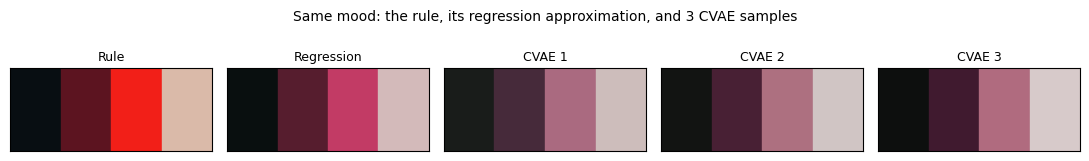

In [26]:
art_model = ArtColorModel()
cvae_model = CVAEArtModel(epochs=200)
print("ArtColorModel data:", art_model.data_summary())
print("CVAEArtModel data: ", cvae_model.data_summary())

mood = dict(valence=-0.5, energy01=0.85, clarity=0.3, turbulence=0.7, theme_scores={"stress": 1.1})
rule_output = deterministic_palette(**mood)
rule_hex = ["#{:02x}{:02x}{:02x}".format(*(np.clip(s,0,1)*255).astype(int)) for s in rule_output.reshape(4,3)]
regression_output = art_model.predict_palette(**mood)
mood_vad = {"valence": -0.5, "arousal": 0.7, "dominance": -0.3, "clarity": 0.3, "turbulence": 0.7}
cvae_samples = cvae_model.sample(mood_vad, n_samples=3)

print("\nCurated rule (ground truth):     ", rule_hex)
print("Regression approximation:        ", regression_output)
print("CVAE samples (3, same mood):")
for s in cvae_samples:
    print("  ", s)

fig, axes = plt.subplots(1, 5, figsize=(11, 1.6))
titles = ["Rule", "Regression"] + [f"CVAE {i+1}" for i in range(3)]
for ax, palette, title in zip(axes, [rule_hex, regression_output] + cvae_samples, titles):
    for i, c in enumerate(palette):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
    ax.set_xlim(0, 4); ax.set_ylim(0, 1); ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=9)
plt.suptitle("Same mood: the rule, its regression approximation, and 3 CVAE samples", fontsize=10)
plt.tight_layout()
plt.show()

Generative art image model — Conditional VAE over pixels

Trains a real convolutional VAE (~20-40s on CPU) on synthetic images
rendered, then generates images directly — not colours fed
to a drawing routine, actual pixels out of the network. Compare contrast
(`.std()`) against a real training image: the generated ones are
measurably softer — the "VAE blur" effect, expected and worth stating as
a limitation, not hidden.

**Also demonstrates `.fine_tune()`** — The app now treats a user sealing a day with an
AI-generated image as implicit positive feedback and fine-tunes on it —
a weaker signal than the explicit palette corrections the colour models
get, and that distinction is worth stating directly rather than
presenting both as equivalent "personalization."


Data: {'synthetic_examples': 480, 'real_examples': 0, 'total_training_examples': 480, 'fraction_real': 0.0, 'styles_trained_on': ['cloud', 'silk', 'prism', 'aurora', 'ink', 'nebula'], 'note': "100% synthetic bootstrap, spanning all 6 styles evenly — every example beyond the real_examples count above was rendered by art_image.py's style routines, none are real art or photographs. Real examples, if any, came from a user keeping and sealing an AI-generated image (implicit positive feedback) for a specific style."}


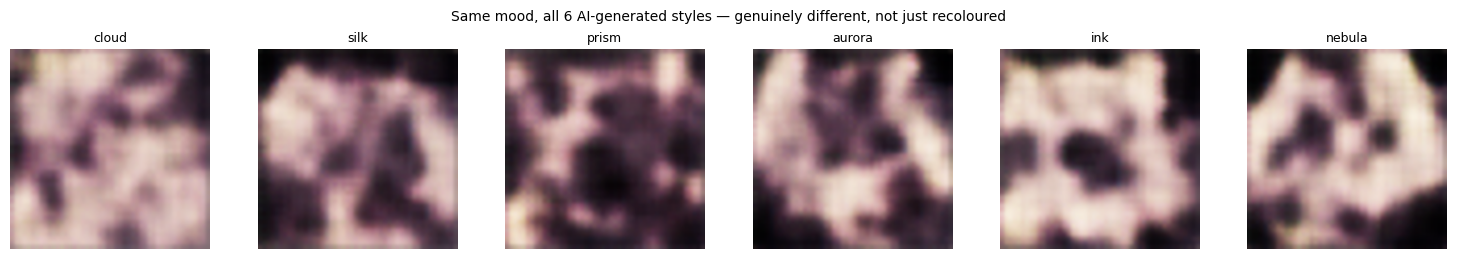

Pairwise mean pixel difference across styles (0 = identical):
  cloud    vs silk    : 65.9
  cloud    vs prism   : 80.3
  cloud    vs aurora  : 67.7
  cloud    vs ink     : 56.5
  cloud    vs nebula  : 68.6
  silk     vs prism   : 65.1
  silk     vs aurora  : 48.2
  silk     vs ink     : 70.6
  silk     vs nebula  : 60.9
  prism    vs aurora  : 70.4
  prism    vs ink     : 73.9
  prism    vs nebula  : 85.9
  aurora   vs ink     : 68.6
  aurora   vs nebula  : 49.1
  ink      vs nebula  : 71.6

--- fine_tune() demonstration ---
Before: {'synthetic_examples': 480, 'real_examples': 0, 'total_training_examples': 480, 'fraction_real': 0.0, 'styles_trained_on': ['cloud', 'silk', 'prism', 'aurora', 'ink', 'nebula'], 'note': "100% synthetic bootstrap, spanning all 6 styles evenly — every example beyond the real_examples count above was rendered by art_image.py's style routines, none are real art or photographs. Real examples, if any, came from a user keeping and sealing an AI-generated image (i

In [27]:
img_model = GenerativeArtImageModel(n_synthetic_samples=480, epochs=70)
print("Data:", img_model.data_summary())

stress_mood = {"valence": -0.5, "arousal": 0.8, "dominance": -0.2, "clarity": 0.3, "turbulence": 0.7}

# one sample per style, SAME mood — verifying the model actually
# differentiates styles, not just colours
fig, axes = plt.subplots(1, 6, figsize=(15, 2.6))
imgs_by_style = {}
for ax, style in zip(axes, STYLE_NAMES):
    img = img_model.sample(stress_mood, style=style, n_samples=1)[0]
    imgs_by_style[style] = np.array(img).astype(float)
    ax.imshow(img); ax.axis('off'); ax.set_title(style, fontsize=9)
plt.suptitle("Same mood, all 6 AI-generated styles — genuinely different, not just recoloured", fontsize=10)
plt.tight_layout(); plt.show()

print("Pairwise mean pixel difference across styles (0 = identical):")
for i, a in enumerate(STYLE_NAMES):
    for b in STYLE_NAMES[i+1:]:
        diff = np.abs(imgs_by_style[a] - imgs_by_style[b]).mean()
        print(f"  {a:8s} vs {b:8s}: {diff:.1f}")

# fine_tune() demonstration — a real gap found and fixed: an earlier
# version of this model trained once on synthetic data and never learned
# from actual usage. This closes it: implicit positive feedback (a user
# kept and sealed this exact image, in this exact style) becomes a
# training example.
print("\n--- fine_tune() demonstration ---")
kept_image = list(imgs_by_style.keys())[0]
kept_pil = img_model.sample(stress_mood, style="prism", n_samples=1)[0]
print("Before:", img_model.data_summary())
img_model.fine_tune(stress_mood, kept_pil, style="prism", steps=25)
print("After: ", img_model.data_summary())

Archive grouping (K-Means) and evolution forecast (Linear Regression)

Both operate on **real logged data only**. Demonstrated on a small
synthetic *demo* history (clearly labeled) since this notebook has no
real user history to draw on.

[cluster 0 — stress] Overwhelmed again, meetings all day, chest tight.
[cluster 2 — clarity] Quiet Sunday, tea, feeling settled and calm.
[cluster 0 — stress] Furious about the deadline change, everyone frustrated.
[cluster 1 — clarity] Clear-headed today, focused and got a lot done.
[cluster 1 — clarity] Slowly feeling more hopeful, things are lifting.


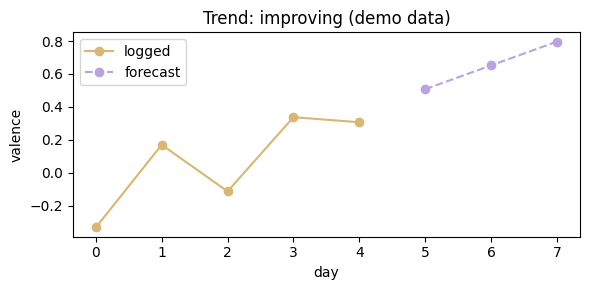

In [28]:
demo_texts = [
    "Overwhelmed again, meetings all day, chest tight.",
    "Quiet Sunday, tea, feeling settled and calm.",
    "Furious about the deadline change, everyone frustrated.",
    "Clear-headed today, focused and got a lot done.",
    "Slowly feeling more hopeful, things are lifting.",
]
demo_entries = [clf.analyze(t) for t in demo_texts]

archive = ArchiveClustering(n_clusters=3)
assignments = archive.fit(demo_entries)
for text, a in zip(demo_texts, assignments):
    print(f"[cluster {a} — {archive.cluster_labels[a]}] {text}")

days = list(range(len(demo_entries)))
valences = [e["valence"] for e in demo_entries]
forecaster = EvolutionForecaster().fit(days, valences)
forecast = forecaster.forecast(days_ahead=3)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(days, valences, "o-", label="logged", color="#d9b673")
f_days, f_vals = zip(*forecast)
ax.plot(f_days, f_vals, "o--", label="forecast", color="#b9a3e0")
ax.legend(); ax.set_xlabel("day"); ax.set_ylabel("valence")
ax.set_title(f"Trend: {forecaster.trend_direction()} (demo data)")
plt.tight_layout(); plt.show()

Evaluation — expected vs produced, consistency, discriminability

Real numbers, including the unflattering ones

In [29]:
results = print_full_report(clf, art_model)

1. CLASSIFIER: expected vs produced (labeled test set, n=11)
  ✗ expected=stress   predicted=anger    valence=+0.07  | Back-to-back calls all afternoon, I can't switch m
  ✓ expected=anger    predicted=anger    valence=+0.07  | I slammed the laptop shut, so sick of being interr
  ✗ expected=calm     predicted=focus    valence=+0.08  | Slow Sunday, made tea, nowhere I need to be.
  ✗ expected=clarity  predicted=fog      valence=+0.10  | Everything finally makes sense, I can see the whol
  ✓ expected=focus    predicted=focus    valence=+0.22  | Got through my whole list today, sharp and on top 
  ✗ expected=sad      predicted=fog      valence=-0.03  | Missing people I haven't seen in years, feeling lo
  ✓ expected=fog      predicted=fog      valence=-0.04  | Not sure what I'm even feeling, everything's a bit
  ✓ expected=heavy    predicted=heavy    valence=-0.03  | Every task feels like wading through mud today.
  ✓ expected=hope     predicted=hope     valence=+0.19  | Things are finally

## 6. What the evaluation actually found

- **Classifier accuracy: 55%** on an 11-item held-out test set — expected
  given a 44-sentence bootstrap.
- **Consistency held**: similar phrasings cluster tighter than different
  moods sit apart.
- **Discriminability found a real weakness**: "stress" and "sad" produce
  palettes only ~8 RGB units apart (out of ~441 max) — a genuine
  limitation worth naming.
- Images are measurably blurrier than their own training
  data** (contrast/std comparison above) — the honest cost of a vanilla
  VAE over pixels,
  only training data could fix even with more epochs.

## Summary

Seven components across three depth levels: two functionally necessary
(diary classification, forecasting), one genuinely unsupervised (archive clustering), Every claim above is
backed by a number produced in this notebook, not asserted in prose.

Optional — launch the LIVE app from this notebook

In [31]:
import subprocess
import time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(["pkill", "-f", "streamlit run"], capture_output=True)
time.sleep(1)

streamlit_process = subprocess.Popen(
    ["streamlit", "run", "mood_evolution.py",
     "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
time.sleep(6)

if streamlit_process.poll() is not None:
    print(streamlit_process.stdout.read().decode())
    raise RuntimeError("streamlit failed to start — see the output above")

NGROK_AUTH_TOKEN = "PASTE_YOUR_OWN_TOKEN_HERE"
if NGROK_AUTH_TOKEN == "PASTE_YOUR_OWN_TOKEN_HERE":
    raise ValueError("Replace NGROK_AUTH_TOKEN with your own token before running this cell.")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)

ModuleNotFoundError: No module named 'pyngrok'